<a href="https://colab.research.google.com/github/FarhanKO/Fraud-Detection/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enterprise Credit Card Fraud Detection Pipeline

## Project Overview
This notebook implements a production-ready, highly robust Machine Learning pipeline for detecting credit card fraud. Financial fraud detection is a highly imbalanced, time-dependent problem where the cost of missing a fraudulent transaction (False Negative) vastly outweighs the cost of a false alarm (False Positive).

To address these real-world business constraints, this project moves beyond standard classification and implements a **Dual-Layer Cascade Architecture** combining Unsupervised Deep Learning and Supervised Gradient Boosting.

## Key Highlights & Methodology

1. **Temporal Validation & Concept Drift:**
   - Avoids data-leakage by using a chronological time-based split rather than random splitting.
   - Implements **Population Stability Index (PSI)** to monitor feature drift and ensure the model remains reliable as transaction patterns evolve over time.

2. **Advanced Feature Engineering:**
   - Derives temporal features (e.g., time of day, night-time transaction flags).
   - Applies non-linear transformations and robust scaling to handle extreme monetary outliers.
   - Generates interaction features between the most predictive principal components and transaction amounts.

3. **Cost-Sensitive Business Evaluation:**
   - Evaluates models not just on F1-Score or ROC-AUC, but on **PR-AUC (Precision-Recall)** and a custom **Banking Risk Cost Function**.
   - Calculates exact dollar amounts at risk to balance the financial penalty of missed fraud against customer friction from false alarms.

4. **Dual-Layer Cascade Architecture (The Engine):**
   - **Layer 1 (Unsupervised Deep Autoencoder):** Acts as a structural filter. It learns the latent representation of *legitimate* transactions. If an incoming transaction has a massive reconstruction error, it is immediately flagged as a Zero-Day/Structural Anomaly.
   - **Layer 2 (Calibrated CatBoost Classifier):** For transactions that pass Layer 1, this model uses historical pattern-matching to predict fraud probabilities. The probabilities are calibrated using **Isotonic Regression** for extreme reliability.

5. **Explainable AI (XAI):**
   - Integrates **SHAP (SHapley Additive exPlanations)** and **Permutation Importance** to ensure every model decision is transparent, interpretable, and auditable by risk teams.

6. **Production Readiness:**
   - Encapsulates preprocessing, feature engineering, and inference logic into a serialized pipeline (`joblib`) ready for real-time deployment.

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer, RobustScaler, MinMaxScaler

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

# Supervised Classification Models
from cuml.linear_model import LogisticRegression
from cuml.neighbors import KNeighborsClassifier
from cuml.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import ComplementNB

# Unsupervised Clustering
from cuml.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_curve, auc,
                            f1_score, precision_score, recall_score, roc_auc_score, average_precision_score,
                            precision_recall_curve)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Analysis

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/AI Projects/Fraud Detection/Fraud Detection.csv")
print("---Glimps of the Dataset---")
display(df.head())

print("\n--- Informations ---")
df.info()
display(df.describe())

print("\n Columns (features):", df.columns.tolist(), "\n")

print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

---Glimps of the Dataset---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Informations ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



 Columns (features): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'] 

Number of samples: 284807
Number of features: 31


Target Class Distribution Count

In [ ]:
print(df['Class'].value_counts(dropna=False))
df = df.dropna(subset=['Class'])  # Drops Row with empty class

Class
0    284315
1       492
Name: count, dtype: int64


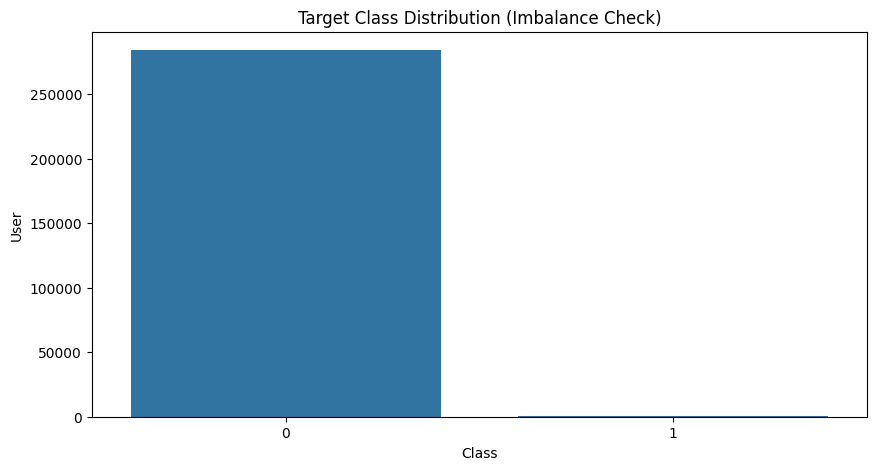

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Class", data=df, order=df["Class"].value_counts().index)

plt.xlabel("Class")
plt.ylabel("User")
plt.title("Target Class Distribution (Imbalance Check)")
plt.show()

### Correlation Analysis (Heatmap)

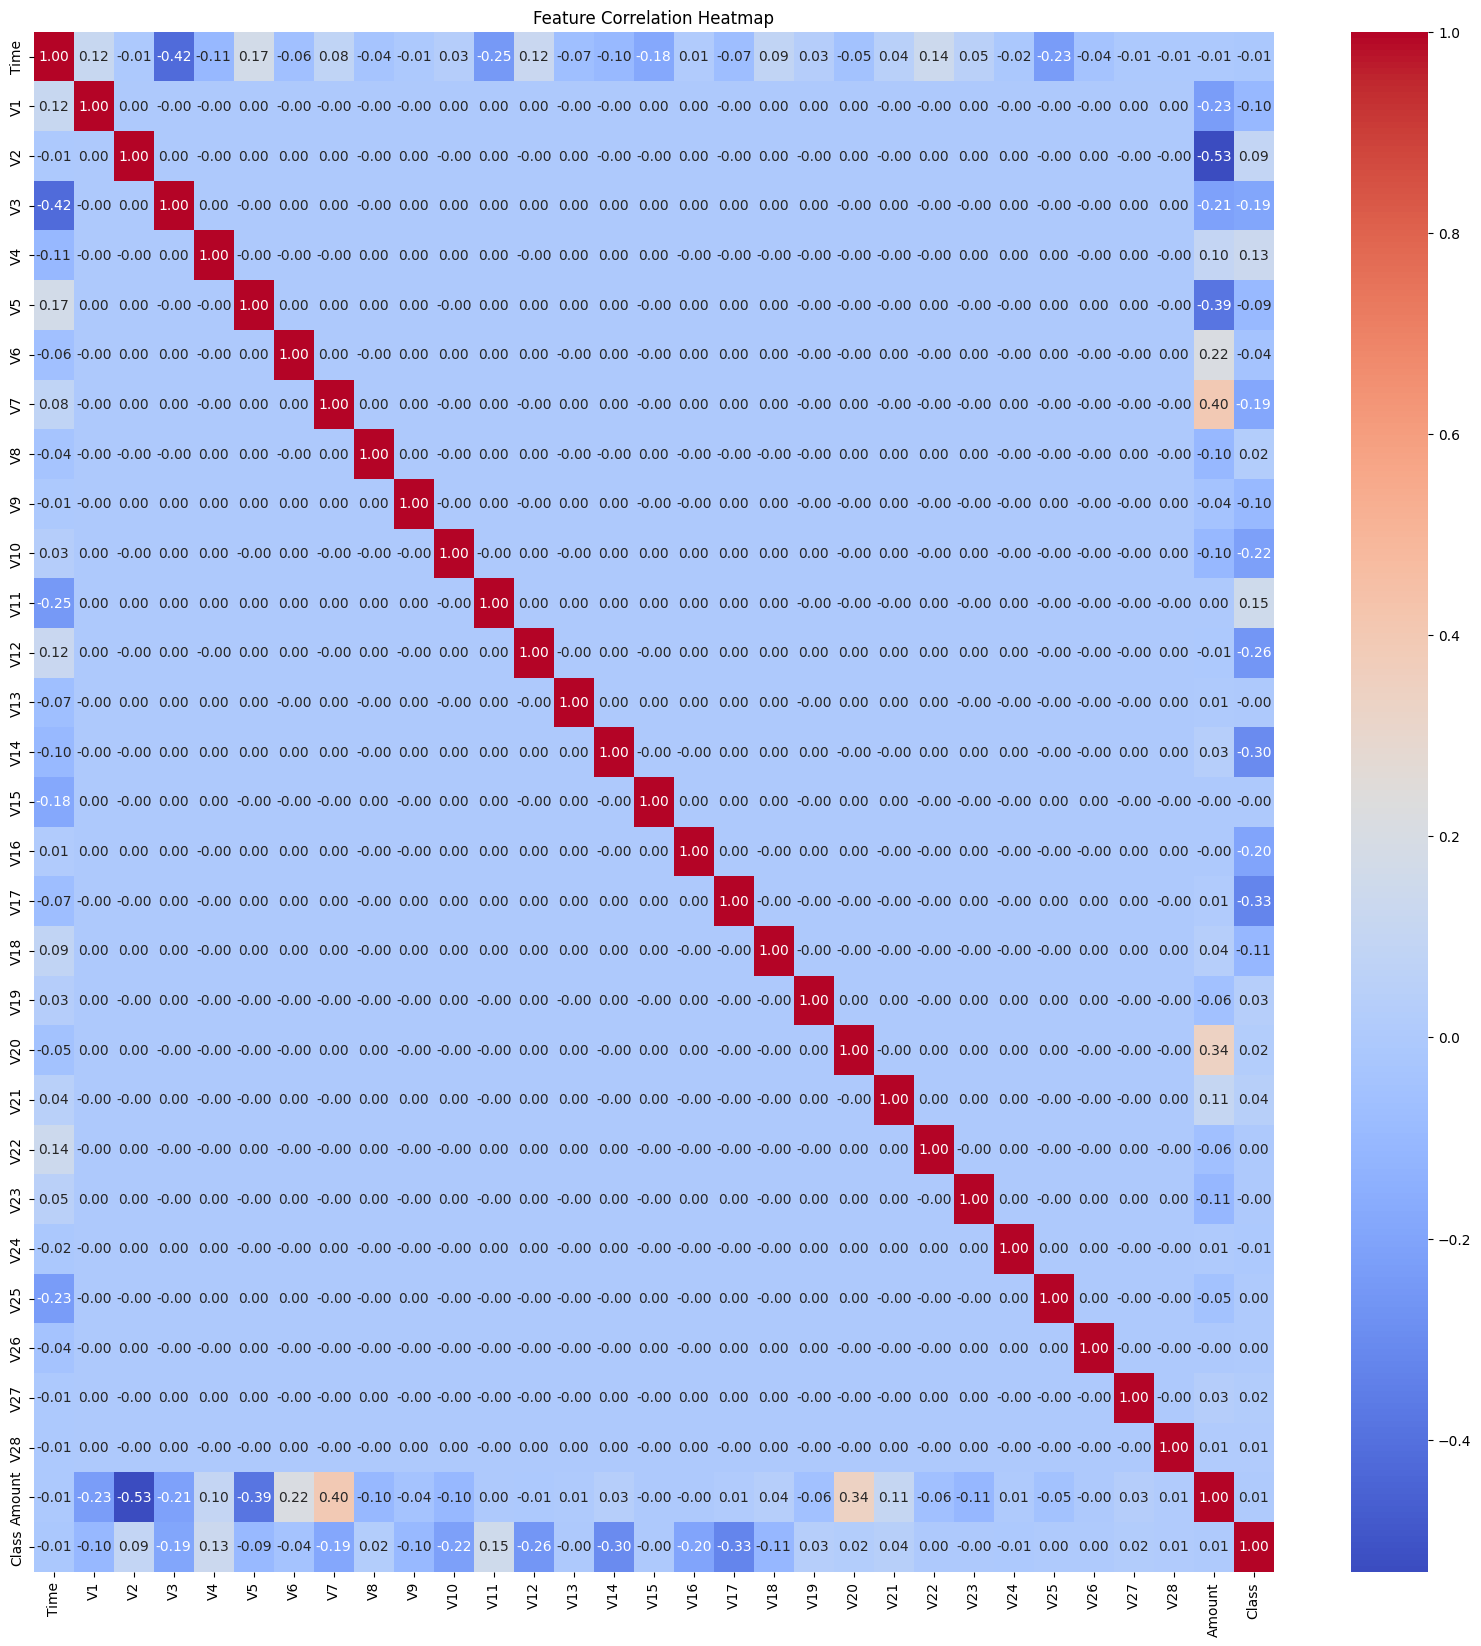

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Auto-drop High Corr Features

In [ ]:
corr_matrix = df.corr(numeric_only=True).abs()   # Calc abs corr and ignore upper triangle
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
df_filtered = df.drop(columns=to_drop)

print("No Features Dropped" if not to_drop else f"Features Dropped: {to_drop}")

No Features Dropped


### Feature Engineering

In [ ]:
# Find the top 5 V-features most correlated with Class (fraud)
top_fraud_features = df.corr(numeric_only=True)['Class'].abs().sort_values(ascending=False)
top_v_features = [col for col in top_fraud_features.index if col.startswith('V')][:5]
print("Top 5 V-features to cross with Amount:", top_v_features)

Top 5 V-features to cross with Amount: ['V17', 'V14', 'V12', 'V10', 'V16']


In [ ]:
def engineer_fraud_features(data):
    df_feat = data.copy()

    # --- TIME-BASED FEATURES ---
    # Convert seconds to hour of the day (0 - 23)
    df_feat['Hour'] = (df_feat['Time'] // 3600) % 24

    # Binary indicator for night hours (12 AM to 5 AM)
    df_feat['Is_Night'] = df_feat['Hour'].apply(lambda x: 1 if (0 <= x <= 5) else 0)

    # --- AMOUNT-BASED FEATURES ---
    # Log transform the amount to handle extreme right-skewness
    df_feat['Log_Amount'] = np.log1p(df_feat['Amount'])

    # Robust Scaling on Amount (handles outliers much better than StandardScaler)
    scaler = RobustScaler()
    df_feat['Scaled_Amount'] = scaler.fit_transform(df_feat[['Amount']])

    # --- INTERACTION FEATURES ---
    for i in top_v_features:
        df_feat[f'{i}_x_Amount'] = df_feat[i] * df_feat['Log_Amount']

    # Time, Amount Dropped since they are now transformed
    df_feat = df_feat.drop(columns=['Time', 'Amount'])

    return df_feat

feature_engineering = FunctionTransformer(engineer_fraud_features)

Fraud detection is a time-dependent problem (patterns change over time) and Random split gives you data leakage-like optimism. So realistically we have to address concept drift in financial fraud detection and so a time-based chronological split was applied instead of Random Split

In [ ]:
X = df.drop(['Class'], axis=1)
y = df['Class']

numerical_existing_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features = numerical_existing_features + ['Hour', 'Is_Night', 'Log_Amount', 'Scaled_Amount']

processor = Pipeline(steps=[
    ('engineering', feature_engineering),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

# --- CONCEPT DRIFT: SEQUENTIAL TIME SPLIT ---
# We drop random shuffling and stratify so data from the "future" doesn't leak into the "past".
df_sorted = df.sort_values(by='Time').reset_index(drop=True)

X_sorted = df_sorted.drop(columns=['Class'])
y_sorted = df_sorted['Class']

# Establish a clean 80% cutoff point for the training window
split_index = int(len(df_sorted) * 0.80)

# Slice sequentially (No random state or stratification needed here)
X_train = X_sorted.iloc[:split_index]
X_test = X_sorted.iloc[split_index:]
y_train = y_sorted.iloc[:split_index]
y_test = y_sorted.iloc[split_index:]

# Preprocessing arrays remain exactly the same for the rest of your notebook cells
X_train_processed = processor.fit_transform(X_train, y_train)
X_test_processed = processor.transform(X_test)

print("=== TEMPORAL PRODUCTION SPLIT COMPLETE ===")
print(f"X_train shape (Past History): {X_train.shape}")
print(f"X_test shape (Future Simulation): {X_test.shape}")

=== TEMPORAL PRODUCTION SPLIT COMPLETE ===
X_train shape (Past History): (227845, 30)
X_test shape (Future Simulation): (56962, 30)


# Concept Drift Monitoring (Population Stability Index - PSI)

Since financial fraud patterns evolve over time, we use the **Population Stability Index (PSI)** to mathematically quantify how much the distribution of each feature has shifted between the historical training data and the future test simulation.

* **PSI < 0.1:** No significant drift (Stable).
* **0.1 ≤ PSI < 0.2:** Moderate drift (Monitor feature).
* **PSI ≥ 0.2:** High drift (Feature distribution has significantly changed).

In [ ]:
def calculate_psi(expected, actual, buckets=10):
    '''Calculates the Population Stability Index (PSI) for continuous variables'''
    # Generate breakpoints from the expected (train) data percentiles
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    # Calculate bucket percentages
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    # Clip zeros to avoid division by zero and log(0) errors
    expected_percents = np.clip(expected_percents, a_min=0.0001, a_max=None)
    actual_percents = np.clip(actual_percents, a_min=0.0001, a_max=None)

    # Calculate actual PSI
    psi_value = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi_value

print("--- Population Stability Index (PSI) Rankings ---")
psi_results = []

# We measure drift on the original unscaled features for better interpretability
for col in X_train.columns:
    psi_val = calculate_psi(X_train[col].values, X_test[col].values)
    psi_results.append({'Feature': col, 'PSI': psi_val})

df_psi = pd.DataFrame(psi_results).sort_values(by='PSI', ascending=False)

# Label the drift severity
df_psi['Drift Severity'] = pd.cut(
    df_psi['PSI'],
    bins=[-1, 0.1, 0.2, np.inf],
    labels=['🟢 Stable (Low)', '🟡 Monitor (Moderate)', '🔴 High Drift']
)

# Display top 10 features with the most drift
display(df_psi.head(10).style.background_gradient(cmap='Reds', subset=['PSI']).format({'PSI': '{:.4f}'}))

--- Population Stability Index (PSI) Rankings ---


,Feature,PSI,Drift Severity
0,Time,8.2829,🔴 High Drift
1,V1,0.8236,🔴 High Drift
3,V3,0.5718,🔴 High Drift
28,V28,0.4003,🔴 High Drift
11,V11,0.2669,🔴 High Drift
25,V25,0.2183,🔴 High Drift
15,V15,0.1658,🟡 Monitor (Moderate)
12,V12,0.1505,🟡 Monitor (Moderate)
5,V5,0.1222,🟡 Monitor (Moderate)
22,V22,0.1190,🟡 Monitor (Moderate)


# Supervised Model Training

In [ ]:
model_results = {}

### Logistic Regression

In [ ]:
log_reg_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced'))
])

log_reg_params = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

log_reg_grid = GridSearchCV(log_reg_pipeline, log_reg_params, cv=5, scoring='average_precision', n_jobs=-1)
log_reg_grid.fit(X_train_processed, y_train)

log_reg_preds = log_reg_grid.best_estimator_.predict(X_test_processed)
log_reg_probas = log_reg_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"cuML Logistic Regression Best Score: {log_reg_grid.best_score_:.4f}")
print(f"\n--- Logistic Regression Metrics ---")
print(classification_report(y_test, log_reg_preds, target_names=['Legit', 'Fraud']))

model_results['Logistic Regression'] = log_reg_grid

cuML Logistic Regression Best Score: 0.7164

--- Logistic Regression Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      0.94      0.97     56887
       Fraud       0.02      0.95      0.04        75

    accuracy                           0.94     56962
   macro avg       0.51      0.94      0.51     56962
weighted avg       1.00      0.94      0.97     56962



### KNN Classifier

In [ ]:
knn_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', KNeighborsClassifier()) # Runs completely on Colab's GPU!
])

knn_params = {
    'classifier__n_neighbors': [3, 5, 7],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=5, scoring='average_precision', n_jobs=-1)
knn_grid.fit(X_train_processed, y_train)

knn_preds = knn_grid.best_estimator_.predict(X_test_processed)
knn_probas = knn_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"cuML KNN Best Score: {knn_grid.best_score_:.4f}")
print(f"\n--- KNN Metrics ---")
print(classification_report(y_test, knn_preds, target_names=['Legit', 'Fraud']))

model_results['KNN'] = knn_grid

cuML KNN Best Score: 0.5807

--- KNN Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.43      0.81      0.56        75

    accuracy                           1.00     56962
   macro avg       0.72      0.91      0.78     56962
weighted avg       1.00      1.00      1.00     56962



### Decesion Tree

In [ ]:
dt_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', XGBClassifier(
        n_estimators=1,       # Forces it to act as a single standalone decision tree
        random_state=42,
        device='cuda',
        tree_method='hist'
    ))
])

dt_params = {
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__learning_rate': [1.0]
}

dt_grid = GridSearchCV(dt_pipeline, dt_params, cv=5, scoring='average_precision', n_jobs=-1)
dt_grid.fit(X_train_processed, y_train)

dt_preds = dt_grid.best_estimator_.predict(X_test_processed)
dt_probas = dt_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"Decesion Tree Best Score: {dt_grid.best_score_:.4f}")
print(f"\n--- Decision Tree Metrics ---")
print(classification_report(y_test, dt_preds, target_names=['Legit', 'Fraud']))

model_results['Decision Tree'] = dt_grid

Decesion Tree Best Score: 0.6494

--- Decision Tree Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.22      0.81      0.35        75

    accuracy                           1.00     56962
   macro avg       0.61      0.90      0.67     56962
weighted avg       1.00      1.00      1.00     56962



### Random Forest

In [ ]:
rf_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 15, 20],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring='average_precision', n_jobs=-1)
rf_grid.fit(X_train_processed, y_train)

rf_preds = rf_grid.best_estimator_.predict(X_test_processed)
rf_probas = rf_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"cuML Random Forest Best Score: {rf_grid.best_score_:.4f}")
print(f"\n--- Random Forest Metrics ---")
print(classification_report(y_test, rf_preds, target_names=['Legit', 'Fraud']))

model_results['Random Forest'] = rf_grid

cuML Random Forest Best Score: 0.7758

--- Random Forest Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.88      0.76      0.81        75

    accuracy                           1.00     56962
   macro avg       0.94      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



### Naive Bayes

In [ ]:
nb_pipeline = ImbPipeline(steps=[
    ('minmax', MinMaxScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', ComplementNB())
])

nb_params = {
    'classifier__alpha': [0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(nb_pipeline, nb_params, cv=5, scoring='average_precision', n_jobs=-1)
nb_grid.fit(X_train_processed, y_train)

nb_preds = nb_grid.best_estimator_.predict(X_test_processed)
nb_probas = nb_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"Naive Bayes Best Score: {nb_grid.best_score_:.4f}")
print(f"\n--- Naive Bayes Metrics ---")
print(classification_report(y_test, nb_preds, target_names=['Legit', 'Fraud']))

model_results['Naive Bayes'] = nb_grid

Naive Bayes Best Score: 0.6848

--- Naive Bayes Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.96      0.32      0.48        75

    accuracy                           1.00     56962
   macro avg       0.98      0.66      0.74     56962
weighted avg       1.00      1.00      1.00     56962



### Neural Network (PyTorch + Skorch)

In [ ]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 22.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from skorch import NeuralNetClassifier

class AdvancedFraudNN(nn.Module):
    def __init__(self, input_dim=37, hidden_dim=64):
        super(AdvancedFraudNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 2)
        )
    def forward(self, X):
        return self.net(X.astype('float32') if hasattr(X, 'astype') else X)

cuda_nn = NeuralNetClassifier(
    AdvancedFraudNN,
    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    device='cuda',
    max_epochs=25,
    batch_size=512,
    verbose=0
)

mlp_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', cuda_nn)
])

mlp_params = {
    'classifier__module__hidden_dim': [64, 128],
    'classifier__lr': [0.001, 0.01]
}

mlp_grid = GridSearchCV(mlp_pipeline, mlp_params, cv=3, scoring='average_precision')

# Data conversion for clean tensor compilation
mlp_grid.fit(X_train_processed.astype('float32'), y_train.values.astype('int64'))

mlp_preds = mlp_grid.best_estimator_.predict(X_test_processed.astype('float32'))
mlp_probas = mlp_grid.best_estimator_.predict_proba(X_test_processed.astype('float32'))[:, 1]

print(f"Neural Network Best Score: {mlp_grid.best_score_:.4f}")
print(f"\n--- Neural Network Metrics ---")
print(classification_report(y_test, mlp_preds, target_names=['Legit', 'Fraud']))

model_results['Neural Network'] = mlp_grid

Neural Network Best Score: 0.6697

--- Neural Network Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     56887
       Fraud       0.03      0.88      0.05        75

    accuracy                           0.95     56962
   macro avg       0.51      0.92      0.51     56962
weighted avg       1.00      0.95      0.98     56962



### XGBoost Classifier

In [ ]:
xgb_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss', device='cuda'))
])

xgb_params = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [100, 200, 300]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_params, cv=5, scoring='average_precision')
xgb_grid.fit(X_train_processed, y_train)

xgb_preds = xgb_grid.best_estimator_.predict(X_test_processed)
xgb_probas = xgb_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"XGBoost Best Score: {xgb_grid.best_score_:.4f}")
print(f"\n--- XGBoost Metrics ---")
print(classification_report(y_test, xgb_preds, target_names=['Legit', 'Fraud']))

model_results['XGBoost'] = xgb_grid

XGBoost Best Score: 0.8097

--- XGBoost Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.79      0.76      0.78        75

    accuracy                           1.00     56962
   macro avg       0.90      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962



### CatBoost Classifier

CatBoost handles tabular interaction terms phenomenally well and natively optimizes symmetric decision trees directly

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

cb_pipeline = ImbPipeline(steps=[
    ('classifier', CatBoostClassifier(
        task_type="GPU",
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    ))
])

cb_params = {
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.03, 0.1],
    'classifier__iterations': [200, 500]
}

cb_grid = GridSearchCV(cb_pipeline, cb_params, cv=5, scoring='average_precision')
cb_grid.fit(X_train_processed, y_train)

cb_preds = cb_grid.best_estimator_.predict(X_test_processed)
cb_probas = cb_grid.best_estimator_.predict_proba(X_test_processed)[:, 1]

print(f"CatBoost Best Score: {cb_grid.best_score_:.4f}")
print(f"\n--- CatBoost Metrics ---")
print(classification_report(y_test, cb_preds, target_names=['Legit', 'Fraud']))

model_results['CatBoost'] = cb_grid

CatBoost Best Score: 0.8107

--- CatBoost Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.90      0.76      0.83        75

    accuracy                           1.00     56962
   macro avg       0.95      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Inside the comparison we will add Missed Fraud Cases & Missed Fraud Amount Because F1-Score or AUC treat all errors equally. But in credit card fraud, a False Negative (missing a 500k fraud transaction) is vastly more expensive than a False Positive (accidentally blocking a legitimate 10$ transaction and annoying a customer). For extra safety build a custom Financial Utility Function to evaluate your models based on actual money saved

$$Cost=α×FN Amount+β×FP Count$$

# Supervised Model Comparison

In [ ]:
amt_test = df.loc[y_test.index, 'Amount'].values
alpha = 1.0
beta = 50.0

### Roc & PR Curve


================================= SUPERVISED ENGINE PERFORMANCE =================================


,Accuracy,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),ROC-AUC,PR-AUC (AP),Missed Fraud Cases,Missed Fraud Amount ($),Banking Risk Cost ($)
Supervised Model,,,,,,,,,
Logistic Regression,0.9416,0.0209,0.9467,0.0409,0.9920,0.5792,4,$371.00,"$166,471.00"
KNN,0.9983,0.4326,0.8133,0.5648,0.9128,0.6282,14,"$1,399.05","$5,399.05"
Decision Tree,0.9960,0.2226,0.8133,0.3496,0.9635,0.7024,14,"$1,426.65","$12,076.65"
Random Forest,0.9995,0.8769,0.7600,0.8143,0.9774,0.8173,18,"$1,661.42","$2,061.42"
Naive Bayes,0.9991,0.9600,0.3200,0.4800,0.9626,0.6946,51,"$3,234.48","$3,284.48"
Neural Network,0.9549,0.0252,0.8800,0.0489,0.9736,0.6648,9,"$1,322.39","$129,222.39"
XGBoost,0.9994,0.7917,0.7600,0.7755,0.9772,0.7899,18,"$1,661.42","$2,411.42"
CatBoost,0.9996,0.9048,0.7600,0.8261,0.9651,0.8095,18,"$1,661.42","$1,961.42"


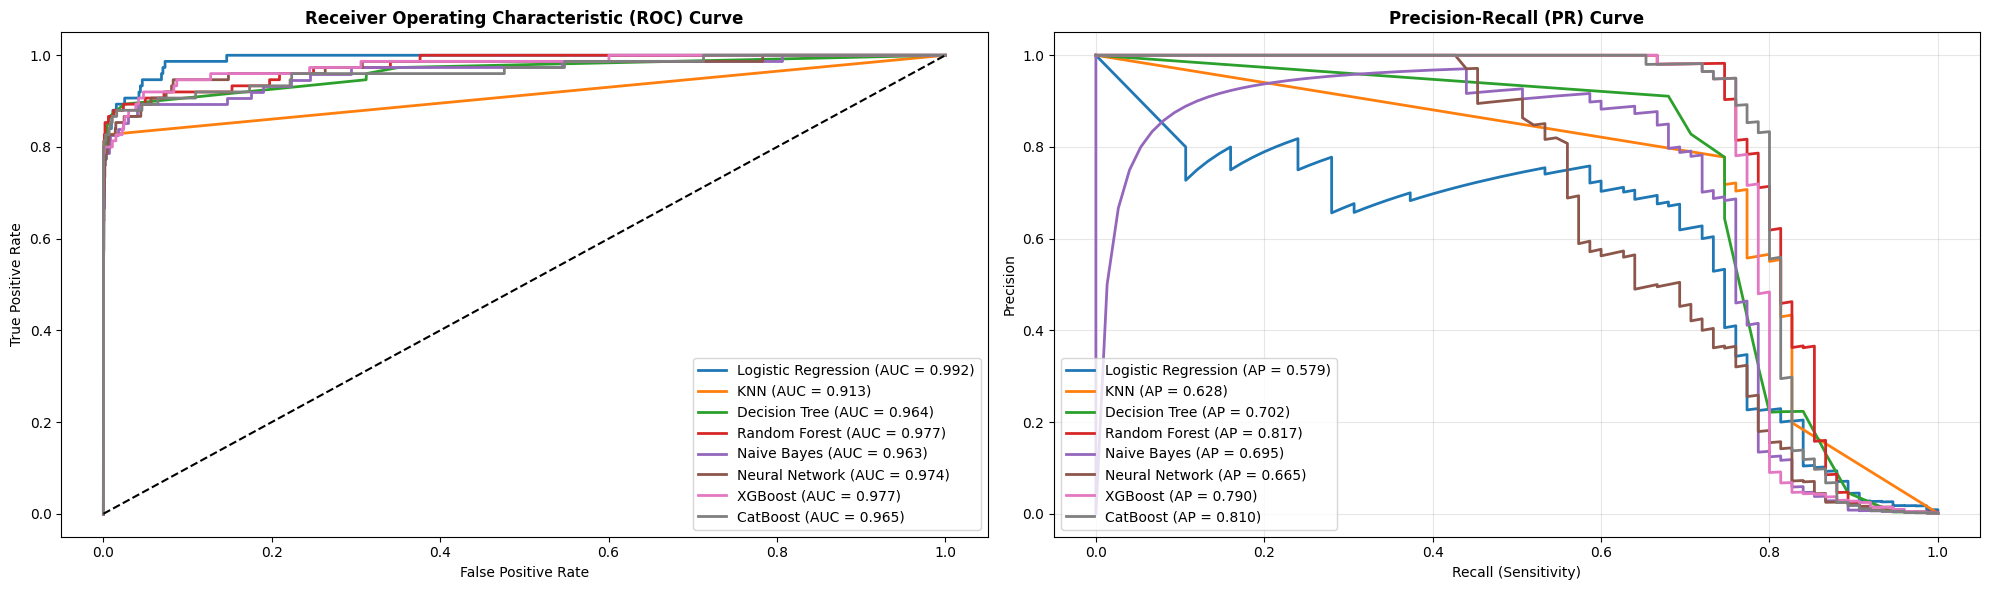

In [ ]:
# We only check the report specifically for the fraud label to determine model performance
supervised_data = []
plt.figure(figsize=(20, 6), dpi=100)
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)

for model_name, grid_obj in model_results.items():
    if model_name in ['Isolation Forest', 'Local Outlier Factor']:
        continue

    best_model = grid_obj.best_estimator_ if hasattr(grid_obj, 'best_estimator_') else grid_obj
    if 'Neural Network' in model_name:
        X_test_tensor = X_test_processed.astype('float32')
        preds = best_model.predict(X_test_tensor)
        probas = best_model.predict_proba(X_test_tensor)[:, 1]
    else:
        preds = best_model.predict(X_test_processed)
        probas = best_model.predict_proba(X_test_processed)[:, 1]

    # Calculate standard metrics
    acc = accuracy_score(y_test, preds)
    prec_fraud = precision_score(y_test, preds, pos_label=1, zero_division=0)
    rec_fraud = recall_score(y_test, preds, pos_label=1, zero_division=0)
    f1_fraud = f1_score(y_test, preds, pos_label=1, zero_division=0)
    roc_auc = auc(*roc_curve(y_test, probas)[:2])
    ap_score = average_precision_score(y_test, probas)

    # --- DYNAMIC BANKING & METRIC EXTRACTION ---
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    # Identify boolean masks where the model completely missed the fraud
    # (True label was 1, but model predicted 0)
    missed_fraud_mask = (y_test == 1) & (preds == 0)
    missed_fraud_count = int(fn)
    missed_fraud_amount = float(np.sum(amt_test[missed_fraud_mask]))

    # Calculate operational risk cost matrix formula
    banking_risk_cost = (alpha * missed_fraud_amount) + (beta * fp)

    supervised_data.append({
        'Supervised Model': model_name,
        'Accuracy': acc,
        'Precision (Fraud)': prec_fraud,
        'Recall (Fraud)': rec_fraud,
        'F1-Score (Fraud)': f1_fraud,
        'ROC-AUC': roc_auc,
        'PR-AUC (AP)': ap_score,
        'Missed Fraud Cases': missed_fraud_count,
        'Missed Fraud Amount ($)': missed_fraud_amount,
        'Banking Risk Cost ($)': banking_risk_cost
    })

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probas)
    ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', lw=2)

    # Plot Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, probas)
    ax_pr.plot(recall, precision, label=f'{model_name} (AP = {ap_score:.3f})', lw=2)

# Format the Supervised Comparison Table DataFrame
df_supervised = pd.DataFrame(supervised_data).set_index('Supervised Model')

print("================================= SUPERVISED ENGINE PERFORMANCE =================================")
# Beautiful multi-column conditional formatting
display(df_supervised.style.background_gradient(
    cmap='Greens',
    subset=['Accuracy', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds',
    subset=['Missed Fraud Cases', 'Missed Fraud Amount ($)', 'Banking Risk Cost ($)']
).format({
    'Accuracy': '{:.4f}', 'Precision (Fraud)': '{:.4f}', 'Recall (Fraud)': '{:.4f}',
    'F1-Score (Fraud)': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Fraud Cases': '{:,.0f}', 'Missed Fraud Amount ($)': '${:,.2f}', 'Banking Risk Cost ($)': '${:,.2f}'
}))

print()
# Finalize and show performance curves
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(loc='lower right')

ax_pr.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.legend(loc='lower left')
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

While the Neural Network achieved a lower false-negative rate (fewer missed fraud cases), it was ultimately disqualified due to its exceptionally poor Precision of 2.8%

### Performance Comparison

The F1-score calculated in your classification table is based on a rigid default probability threshold of 0.5. If a transaction has a 50.1% risk score, the model labels it "Fraud"; if it has 49.9%, it labels it "Legit." So we ignore F1 here

While all models achieved deceptively high ROC-AUC scores due to the massive volume of legitimate transactions, the Precision-Recall curve ignores the millions of easy legitimate transactions and focuses exclusively on the needle in the haystack: Fraud

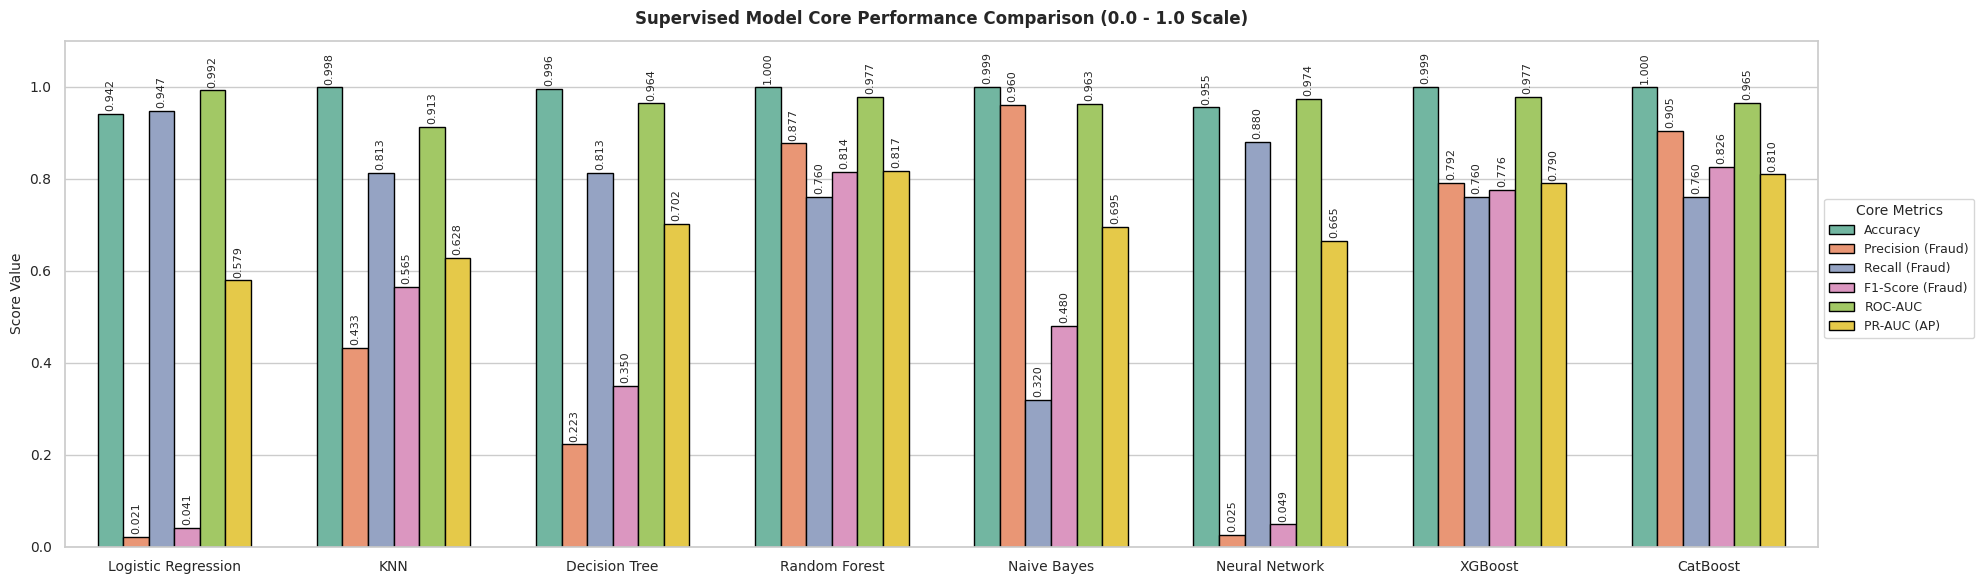

In [ ]:
standard_metrics = [
    'Accuracy', 'Precision (Fraud)', 'Recall (Fraud)',
    'F1-Score (Fraud)', 'ROC-AUC', 'PR-AUC (AP)'
]

df_standard_only = df_supervised[standard_metrics].reset_index()

# Melt ONLY the scaled performance scores
df_melted = df_standard_only.melt(
    id_vars='Supervised Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(20, 6), dpi=100)
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted,
    x='Supervised Model', y='Score',
    hue='Metric', palette='Set2', edgecolor='black', width=0.7)

plt.title('Supervised Model Core Performance Comparison (0.0 - 1.0 Scale)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('', fontsize=10)
plt.ylabel('Score Value', fontsize=10)
plt.ylim(0, 1.1)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Core Metrics', loc='lower left', bbox_to_anchor=(1, 0.4), fontsize=9, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

## Pick the best model

XGBoost provides significantly faster real-time inference speeds, a lighter memory footprint on production servers, and native handling of missing transaction data without requiring a complex data-imputation pipeline. SO if same score we pick XGBoost rather than Cat or RF

In [ ]:
metrics_df = pd.DataFrame(supervised_data)

# Round the Precision-Recall Area Under the Curve (PR-AUC) scores
metrics_df['Rounded_PR'] = metrics_df['PR-AUC (AP)'].round(3)
max_rounded_score = metrics_df['Rounded_PR'].max()

top_models_df = metrics_df[metrics_df['Rounded_PR'] == max_rounded_score]

priority = ['XGBoost', 'CatBoost', 'Random Forest']
best_model_name = None

for model in priority:
    if model in top_models_df['Supervised Model'].values:
        best_model_name = model
        break

# Fallback to the numerical highest score if none of your priority models are present
if best_model_name is None:
    best_model_name = top_models_df['Supervised Model'].iloc[0]

# Extract the physical model object and the exact precision score
best_model_obj = model_results[best_model_name]
exact_score = metrics_df[metrics_df['Supervised Model'] == best_model_name]['PR-AUC (AP)'].values[0]


print(f"🎯 Total models within the top tier: {len(top_models_df)}")
print(f"🏆 Practical Winner: {best_model_name} (PR-AUC: {exact_score:.4f})")

🎯 Total models within the top tier: 1
🏆 Practical Winner: Random Forest (PR-AUC: 0.8173)


### Confusion Matrix and Threshold Analysis

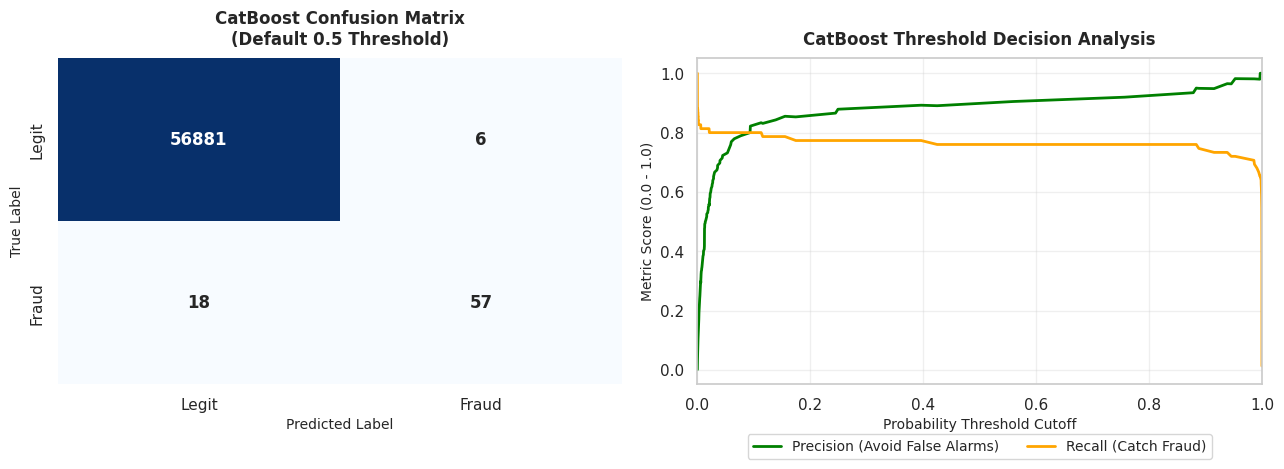


========================= OPERATIONAL BUSINESS IMPACT TABLE =========================


,Caught Fraud (True Positives),Missed Fraud (False Negatives),False Alarms (False Positives),Legit Blocked Rate
Threshold,,,,
0.1,60,15,12,0.021%
0.2,58,17,9,0.016%
0.3,58,17,7,0.012%
0.5,57,18,6,0.011%
0.7,57,18,5,0.009%
0.9,55,20,3,0.005%


In [ ]:
cb_grid = model_results['CatBoost']
best_cb = cb_grid.best_estimator_ if hasattr(cb_grid, 'best_estimator_') else cb_grid

# Generate raw predicted probabilities for the test set
cb_probas = best_cb.predict_proba(X_test_processed)[:, 1]

plt.figure(figsize=(13, 5), dpi=100)

# Create the standard 0.5 predictions
default_preds = np.where(cb_probas >= 0.5, 1, 0)
cm = confusion_matrix(y_test, default_preds)

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('CatBoost Confusion Matrix\n(Default 0.5 Threshold)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# THRESHOLD OVERLAY ANALYSIS
# Calculate precision and recall across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, cb_probas)

plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision (Avoid False Alarms)', color='green', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall (Catch Fraud)', color='orange', lw=2)

plt.title('CatBoost Threshold Decision Analysis', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Probability Threshold Cutoff', fontsize=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=10)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

# SIMULATION TABLE
test_thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
simulation_data = []

for t in test_thresholds:
    sim_preds = np.where(cb_probas >= t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, sim_preds).ravel()

    simulation_data.append({
        'Threshold': t,
        'Caught Fraud (True Positives)': tp,
        'Missed Fraud (False Negatives)': fn,
        'False Alarms (False Positives)': fp,
        'Legit Blocked Rate': f"{(fp / (tn + fp)) * 100:.3f}%"
    })

df_sim = pd.DataFrame(simulation_data).set_index('Threshold')
print("\n========================= OPERATIONAL BUSINESS IMPACT TABLE =========================")
display(df_sim)

We will 0.2 if your business priority is catching maximum fraud. Going lower to 0.1 causes false alarms to jump up too aggressively (+14 alarms) just to save 2 extra fraud case.

And 0.3 if you want the absolute cleanest mathematical equilibrium between precision and recall.

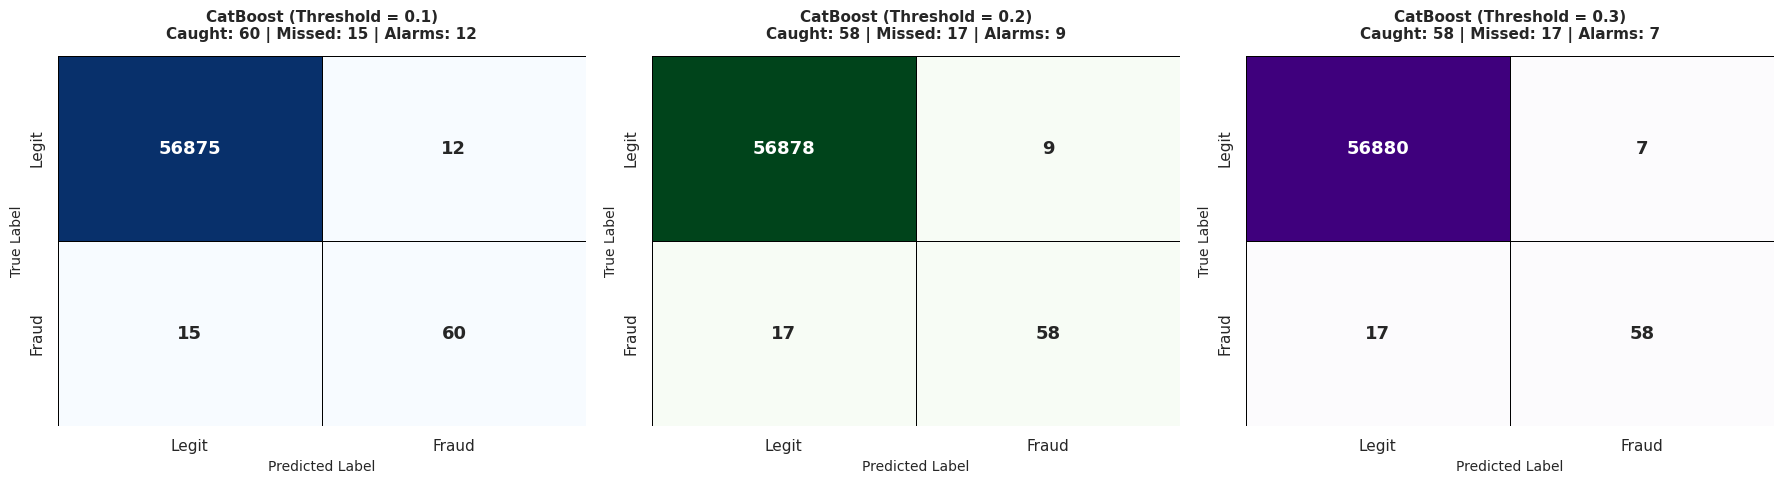

In [ ]:
thresholds_to_plot = [0.1, 0.2, 0.3]
colormaps = ['Blues', 'Greens', 'Purples']

# Initialize a wide canvas to fit all 3 heatmaps nicely
plt.figure(figsize=(18, 5), dpi=100)

for i, (t, cmap) in enumerate(zip(thresholds_to_plot, colormaps), 1):
    # Generate predictions dynamically for the current threshold
    preds = np.where(cb_probas >= t, 1, 0)
    cm = confusion_matrix(y_test, preds)

    # Create the 1 row, 3 columns grid position
    plt.subplot(1, 3, i)

    # Draw the heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
                annot_kws={'size': 13, 'weight': 'bold'}, linecolor='black', linewidth=0.5)

    # Extract structural metrics for the title to show faculty the differences instantly
    tn, fp, fn, tp = cm.ravel()
    plt.title(f'CatBoost (Threshold = {t})\nCaught: {tp} | Missed: {fn} | Alarms: {fp}',
              fontsize=11, fontweight='bold', pad=12)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

### Calibrate CatBoost Probabilities

Fraud systems often require trustworthy probabilities for cost-benefit analysis and dynamic thresholding. Here, we apply **Isotonic Regression** to calibrate the raw probabilities from the CatBoost model, making sure the predicted probability matches the true empirical likelihood of fraud.

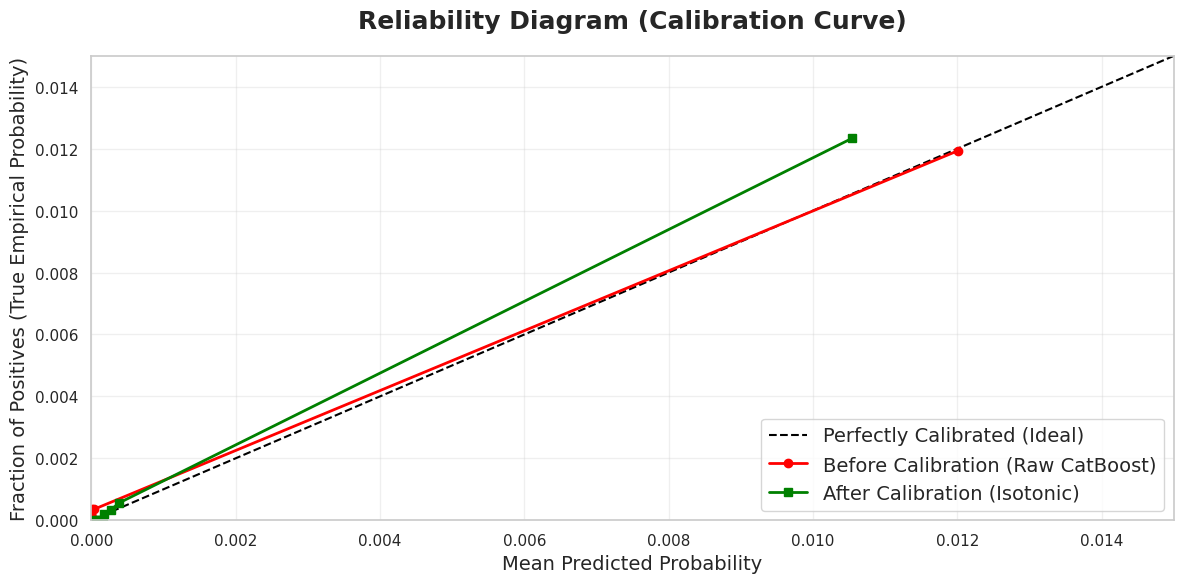

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_cb_pipeline = cb_grid.best_estimator_

# Wrap the winning CatBoost pipeline with a CalibratedClassifierCV
# cv=3 will cross-validate and retrain the model internally to avoid data leakage during calibration
calibrated_cb = CalibratedClassifierCV(estimator=best_cb_pipeline, method='isotonic', cv=3)
calibrated_cb.fit(X_train_processed, y_train)

# Generate probabilities for both models
raw_probas = best_cb_pipeline.predict_proba(X_test_processed)[:, 1]
calib_probas = calibrated_cb.predict_proba(X_test_processed)[:, 1]

# Compute the points for the calibration curves
# We use strategy='quantile' since fraud is highly imbalanced
prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_probas, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calib_probas, n_bins=10, strategy='quantile')

# Plot the Reliability Diagram
plt.figure(figsize=(12, 6), dpi=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')

plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', lw=2, label='Before Calibration (Raw CatBoost)')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='green', lw=2, label='After Calibration (Isotonic)')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=14)
plt.ylabel('Fraction of Positives (True Empirical Probability)', fontsize=14)
plt.legend(loc='lower right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0.0, 0.015)
plt.ylim(0.0, 0.015)
plt.tight_layout()
plt.show()

This line shows the calibration after applying Isotonic Regression. You can see that the green line is much closer to the black dashed line than the red line. This demonstrates that the isotonic calibration has improved the model's reliability, making its predicted probabilities a better reflection of the true likelihood of fraud.

In [ ]:
# Generate hard predictions (using default 0.5 threshold) for the calibrated model
calib_preds = calibrated_cb.predict(X_test_processed)
raw_preds = best_cb_pipeline.predict(X_test_processed)

def get_eval_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC (AP)': average_precision_score(y_true, y_prob)
    }

# Build comparison dataframe
calib_comparison_df = pd.DataFrame({
    'Raw CatBoost': get_eval_metrics(y_test, raw_preds, raw_probas),
    'Calibrated CatBoost': get_eval_metrics(y_test, calib_preds, calib_probas)
}).T

print("--- Impact of Isotonic Calibration on Metrics ---")
display(calib_comparison_df.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0))

--- Impact of Isotonic Calibration on Metrics ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP)
Raw CatBoost,0.9996,0.9048,0.7600,0.8261,0.9651,0.8095
Calibrated CatBoost,0.9996,0.9483,0.7333,0.8271,0.9793,0.8042


### Feature Importance for CatBoost

#### Shap Analysis

SHAP explains how each feature impacts the prediction of each individual instance `(1 instance's impact for 1 feature)`

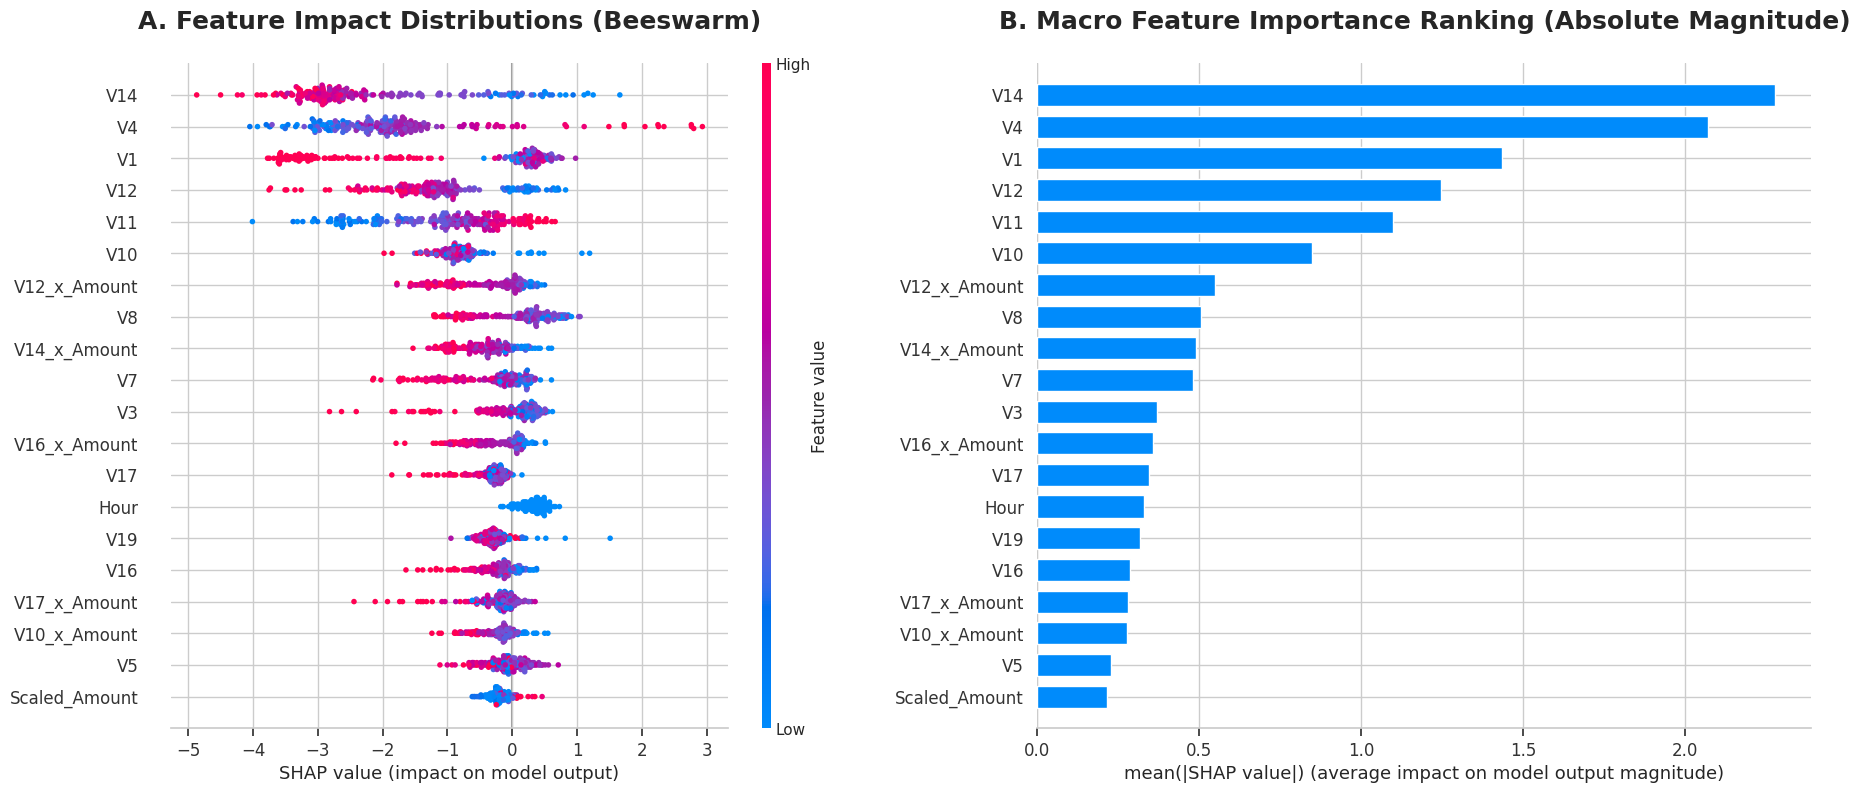

In [ ]:
import shap
import matplotlib.gridspec as gridspec

best_pipeline = cb_grid.best_estimator_ if hasattr(cb_grid, 'best_estimator_') else cb_grid
processor = best_pipeline[0]
model_object = best_pipeline.named_steps['classifier']

# Extract the perfectly ordered feature names straight from the transformer
try:
    raw_feature_names = processor.get_feature_names_out()
    feature_names = [name.split('__')[-1] for name in raw_feature_names]
except AttributeError:
    feature_names = engineer_fraud_features(X_test.head(1)).columns.tolist()

# Extract your sample array
X_sample = X_test_processed[:200]

# Compute SHAP values
explainer = shap.TreeExplainer(model_object)
shap_values = explainer(X_sample)

fig = plt.figure(figsize=(32, 10), dpi=100)
gs = gridspec.GridSpec(1, 21)

ax1 = plt.subplot(gs[0, 0:9])
ax2 = plt.subplot(gs[0, 11:21])

# --- LEFT PLOT: Feature Impact Distributions (Beeswarm) ---
plt.sca(ax1)
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
ax1.set_title('A. Feature Impact Distributions (Beeswarm)', fontsize=18, fontweight='bold', pad=25)
ax1.tick_params(axis='both', labelsize=12)

# --- RIGHT PLOT: Average Absolute SHAP Value (Global Bar) ---
plt.sca(ax2)
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    feature_names=feature_names,
    max_display=20,
    show=False
)
ax2.set_title('B. Macro Feature Importance Ranking (Absolute Magnitude)', fontsize=18, fontweight='bold', pad=25)
ax2.tick_params(axis='both', labelsize=12)

plt.subplots_adjust(left=0.05, right=2.1, top=0.85, bottom=0.15)
plt.show()


Right side (+value) → FRAUD (1)   **&**   Left side (-value) → LEGIT (0)

Feature impact V14 > V4 > V1... > Log_Amount

#### Permutational Importance

**Permutation Importance** how shuffling each feature affects overall predictive performance `(Overall Impact for 1 feature)`



In [ ]:
from sklearn.inspection import permutation_importance

# Raw classifier and processed data sample directly
classifier = cb_grid.best_estimator_.named_steps['classifier']
X_test_transformed = X_test_processed  # Use your already processed matrix

# Extract your engineered feature names directly from your custom function
feature_names = engineer_fraud_features(X_test.head(1)).columns.tolist()

# Compute permutation importance
result = permutation_importance(
    classifier, X_test_transformed, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

df_perm_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': result.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print("--- Permutation Importance (True Model Impact) ---")
print(df_perm_importance.head(10))

--- Permutation Importance (True Model Impact) ---
     Feature  Importance_Mean
13       V14         0.000523
11       V12         0.000068
3         V4         0.000056
6         V7         0.000047
10       V11         0.000035
2         V3         0.000021
0         V1         0.000019
26       V27         0.000004
4         V5         0.000002
29  Is_Night         0.000000


In contrast to the SHAP analysis, where V14, V7 and V4 were crucial, the permutation importance shows that overall model performance drops most when log_amount and scaled_amount are shuffled. V14 still plays a strong role but features like V5 and V17_x_Amount have less overall global impact

# Unsupervised Learning

### Anomaly Risk Analysis

#### Isolation Forest

It isolates anomalies rather than profiling normal points. It recursively partitions the dataset by randomly selecting features and split values. Since anomalies are few and structurally different, they require fewer splits to be isolated. It is highly efficient for high-dimensional financial data and significantly reduces false positives compared to traditional distance-based methods.

In [ ]:
from sklearn.ensemble import IsolationForest

if_model = IsolationForest(contamination=0.002, random_state=42, n_jobs=-1)

if_model.fit(X_train_processed)
if_raw_preds = if_model.predict(X_test_processed)

# Convert: 1 = normal, -1 = anomaly
if_preds = np.where(if_raw_preds == -1, 1, 0)

print(f"\n--- Isolation Forest Metrics ---")
print(classification_report(y_test, if_preds, target_names=['Legit', 'Fraud']))

model_results['Isolation Forest'] = if_model


--- Isolation Forest Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.04      0.04      0.04        75

    accuracy                           1.00     56962
   macro avg       0.52      0.52      0.52     56962
weighted avg       1.00      1.00      1.00     56962



#### Local Outlier Factor (LOF)

It relies on geometric distance to find anomalies, meaning features with much larger numerical ranges will completely dominate the calculation. Scaling standardizes all features onto an equal playing field, ensuring the algorithm can detect density variations across all variables rather than becoming blind to smaller-scaled metrics.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof_scaler = RobustScaler()
X_train_scaled = lof_scaler.fit_transform(X_train_processed)
X_test_scaled = lof_scaler.transform(X_test_processed)

X_train_legit = X_train_scaled[y_train == 0]
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.002, novelty=True)
lof_model.fit(X_train_legit)

# (LOF outputs 1 for normal, -1 for anomalies)
lof_raw_preds = lof_model.predict(X_test_scaled)
lof_final_preds = np.where(lof_raw_preds == -1, 1, 0)

print(f"\n--- Outlier Factor Metrics ---")
print(classification_report(y_test, lof_final_preds, target_names=['Legit', 'Fraud']))

model_results['Local Outlier Factor'] = lof_model


--- Outlier Factor Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.02      0.05      0.03        75

    accuracy                           0.99     56962
   macro avg       0.51      0.52      0.51     56962
weighted avg       1.00      0.99      1.00     56962



#### PyOD Library Installation
We will use the PyOD (Python Outlier Detection) library, which is a comprehensive and scalable toolkit for detecting outlying objects. It contains optimized implementations for ECOD, COPOD, and Autoencoders.

In [ ]:
!pip install pyod

### ECOD (Empirical Cumulative Distribution Functions for Outlier Detection)

It is a fast, highly scalable, and parameter-free anomaly detection algorithm. It works by estimating the empirical cumulative distribution of each feature independently. It is particularly effective for high-dimensional financial data because it avoids distance calculations (which suffer from the curse of dimensionality) and requires zero hyperparameter tuning, making it robust against complex fraud distributions.

In [ ]:
from pyod.models.ecod import ECOD

ecod_model = ECOD(contamination=0.002)
ecod_model.fit(X_train_processed)

# PyOD models inherently output 0 for normal (inliers) and 1 for anomalies (outliers)
ecod_preds = ecod_model.predict(X_test_processed)

print(f"\n--- ECOD Metrics ---")
print(classification_report(y_test, ecod_preds, target_names=['Legit', 'Fraud']))

model_results['ECOD'] = ecod_model


--- ECOD Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.02      0.01      0.01        75

    accuracy                           1.00     56962
   macro avg       0.51      0.51      0.51     56962
weighted avg       1.00      1.00      1.00     56962



### COPOD (Copula-Based Outlier Detection)

It uses empirical copula models to estimate tail probabilities and predict anomalies. Like ECOD, it is computationally highly efficient and parameter-free. It excels in capturing multi-dimensional interactions without assuming a specific underlying statistical distribution, making it highly robust against the non-linear distributions often found in credit card fraud.

In [ ]:
from pyod.models.copod import COPOD

copod_model = COPOD(contamination=0.002)
copod_model.fit(X_train_processed)

copod_preds = copod_model.predict(X_test_processed)

print(f"\n--- COPOD Metrics ---")
print(classification_report(y_test, copod_preds, target_names=['Legit', 'Fraud']))

model_results['COPOD'] = copod_model


--- COPOD Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.13      0.11      0.12        75

    accuracy                           1.00     56962
   macro avg       0.56      0.55      0.56     56962
weighted avg       1.00      1.00      1.00     56962



### Deep Autoencoder

Deep neural networks trained strictly on legitimate transactions to learn their latent representation and reconstruct them. Because the model has never seen fraud during training, fraudulent transactions will yield a high reconstruction error. This method is exceptionally powerful for identifying subtle, non-linear hidden relationships in fraud that linear or distance-based algorithms might miss.

In [ ]:
from pyod.models.auto_encoder import AutoEncoder

# AutoEncoder uses deep learning to compress and reconstruct transactions
# Default hidden architecture and training parameters are used to maintain compatibility
ae_model = AutoEncoder(
    contamination=0.002
)

ae_model.fit(X_train_processed)
ae_preds = ae_model.predict(X_test_processed)

print(f"\n--- Autoencoder Metrics ---")
print(classification_report(y_test, ae_preds, target_names=['Legit', 'Fraud']))

model_results['Autoencoder'] = ae_model

Training: 100%|██████████| 10/10 [03:31<00:00, 21.16s/it]



--- Autoencoder Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.24      0.20      0.22        75

    accuracy                           1.00     56962
   macro avg       0.62      0.60      0.61     56962
weighted avg       1.00      1.00      1.00     56962



### Anomaly Detection Model Comparison

In [ ]:
unsupervised_data = []

for model_name, grid_obj in model_results.items():
    if model_name not in ['Isolation Forest', 'Local Outlier Factor', 'ECOD', 'COPOD', 'Autoencoder']:
        continue

    if grid_obj is None:
        print(f"Warning: '{model_name}' entry in model_results is None. Skipping.")
        continue

    # Unsupervised models were saved directly without GridSearchCV wrappers
    best_model = grid_obj

    # Model-specific feature matrices and continuous scoring methods
    if model_name == "Isolation Forest":
        preds_raw = best_model.predict(X_test_processed)
        preds = np.where(preds_raw == -1, 1, 0)
        scores = -best_model.decision_function(X_test_processed)

    elif model_name == "Local Outlier Factor":
        # Check if X_test_scaled exists from your setup, otherwise default to X_test_processed
        features_to_use = X_test_scaled if 'X_test_scaled' in locals() else X_test_processed
        preds_raw = best_model.predict(features_to_use)
        preds = np.where(preds_raw == -1, 1, 0)
        scores = -best_model.decision_function(features_to_use)

    elif model_name in ['ECOD', 'COPOD', 'Autoencoder']:
        preds = best_model.predict(X_test_processed)
        scores = best_model.decision_function(X_test_processed)

    # Traditional classification metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label=1, zero_division=0)
    rec = recall_score(y_test, preds, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)

    # AUC separability metrics
    roc_auc = roc_auc_score(y_test, scores)
    ap_score = average_precision_score(y_test, scores)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    # Raw banking asset losses and operational risk costs
    missed_fraud_mask = (y_test == 1) & (preds == 0)
    missed_fraud_cases = int(fn)
    missed_fraud_amount = float(np.sum(amt_test[missed_fraud_mask]))

    banking_risk_cost = (alpha * missed_fraud_amount) + (beta * fp)

    unsupervised_data.append({
        'Unsupervised Model': model_name,
        'Accuracy': acc,
        'Precision (Fraud)': prec,
        'Recall (Fraud)': rec,
        'F1-Score (Fraud)': f1,
        'ROC-AUC (Score)': roc_auc,
        'PR-AUC (Score)': ap_score,
        'Missed Fraud Cases': missed_fraud_cases,
        'Missed Fraud Amount ($)': missed_fraud_amount,
        'Banking Risk Cost ($)': banking_risk_cost
    })

print("================================= UNSUPERVISED ENGINE PERFORMANCE =================================")
df_unsupervised = pd.DataFrame(unsupervised_data).set_index('Unsupervised Model')

display(df_unsupervised.style.background_gradient(
    cmap='Greens',
    subset=['Accuracy', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)', 'ROC-AUC (Score)', 'PR-AUC (Score)']
).background_gradient(
    cmap='Reds',
    subset=['Missed Fraud Cases', 'Missed Fraud Amount ($)', 'Banking Risk Cost ($)']
).format({
    'Accuracy': '{:.4f}',
    'Precision (Fraud)': '{:.4f}',
    'Recall (Fraud)': '{:.4f}',
    'F1-Score (Fraud)': '{:.4f}',
    'ROC-AUC (Score)': '{:.4f}',
    'PR-AUC (Score)': '{:.4f}',
    'Missed Fraud Cases': '{:,.0f}',
    'Missed Fraud Amount ($)': '${:,.2f}',
    'Banking Risk Cost ($)': '${:,.2f}'
}))

================================= UNSUPERVISED ENGINE PERFORMANCE =================================


,Accuracy,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),ROC-AUC (Score),PR-AUC (Score),Missed Fraud Cases,Missed Fraud Amount ($),Banking Risk Cost ($)
Unsupervised Model,,,,,,,,,
Isolation Forest,0.9975,0.0423,0.0400,0.0411,0.9537,0.0520,72,"$4,168.58","$7,568.58"
Local Outlier Factor,0.9946,0.0165,0.0533,0.0252,0.7937,0.0111,71,"$4,171.49","$16,121.49"
ECOD,0.9977,0.0167,0.0133,0.0148,0.9572,0.0759,74,"$4,134.75","$7,084.75"
COPOD,0.9979,0.1270,0.1067,0.1159,0.9546,0.1097,67,"$3,887.02","$6,637.02"
Autoencoder,0.9981,0.2419,0.2000,0.2190,0.9610,0.1870,60,"$3,342.79","$5,692.79"


*Autoencoder captured significantly more fraud and reduced the bank's operational financial risk by nearly half*

================================== UNSUPERVISED ANOMALY CHECKS ==================================


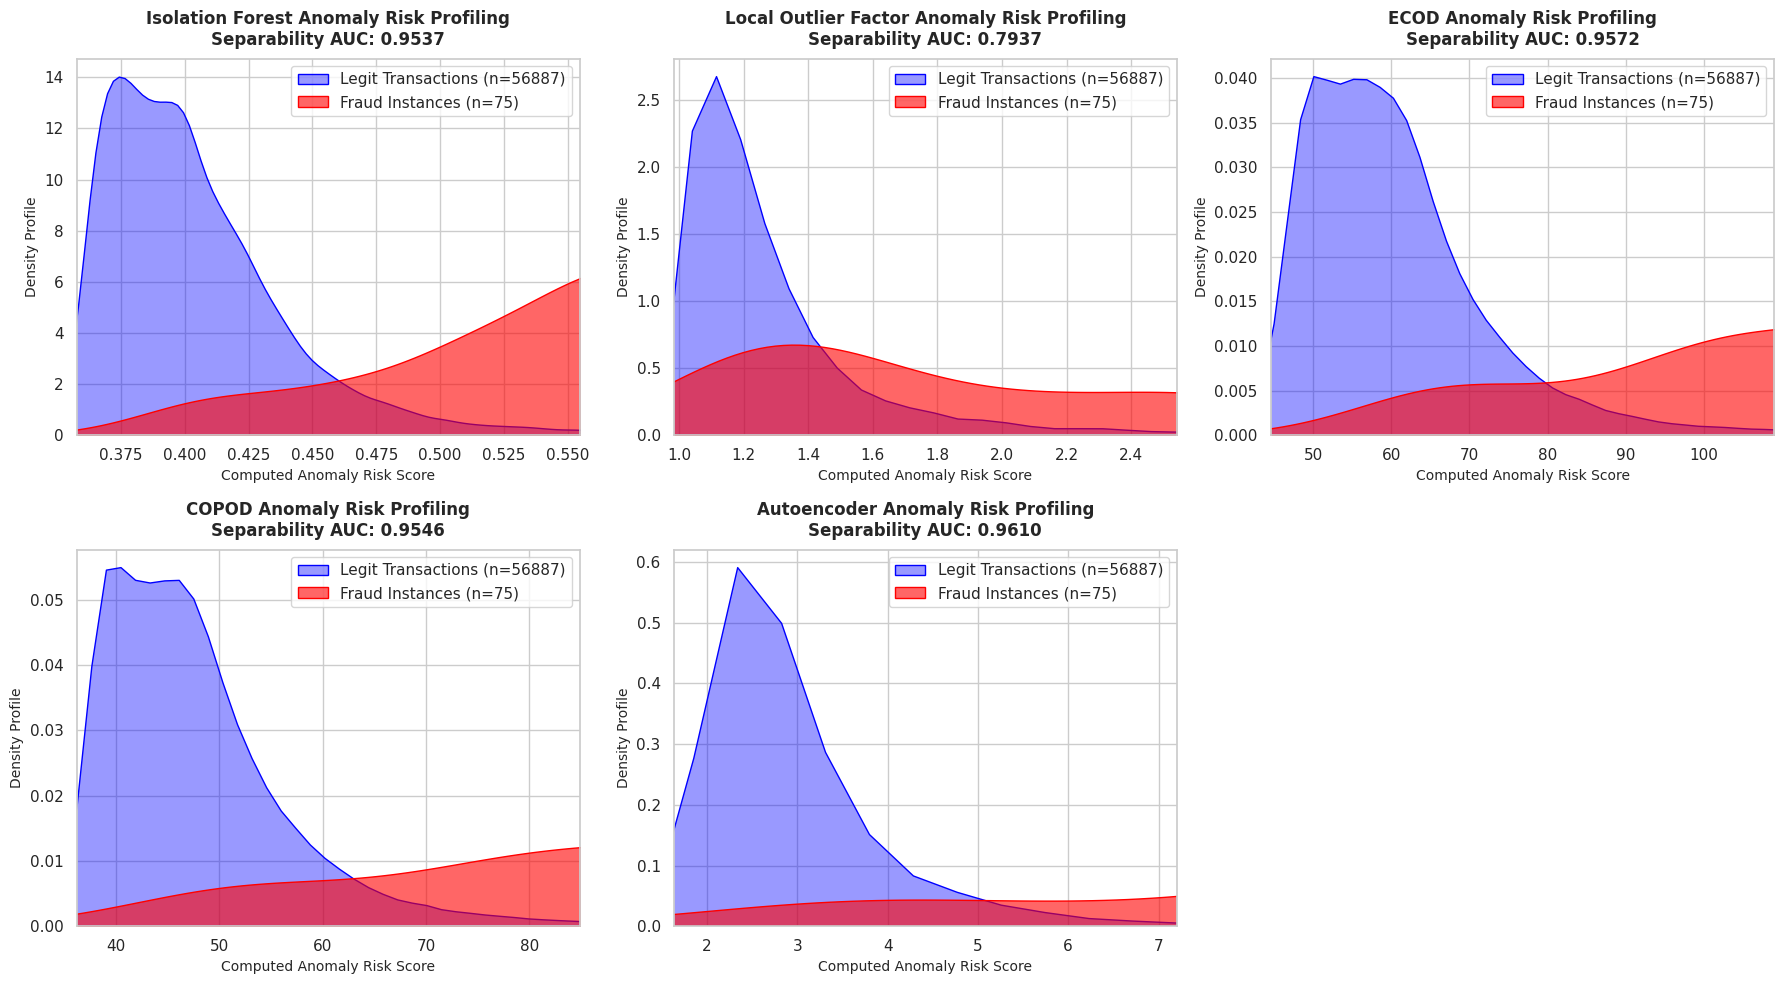

In [ ]:
plt.figure(figsize=(18, 10), dpi=100)

subplot_index = 1

for model_name in ['Isolation Forest', 'Local Outlier Factor', 'ECOD', 'COPOD', 'Autoencoder']:

    if model_name not in model_results:
        continue

    wrapped_obj = model_results[model_name]

    if model_name == 'Isolation Forest' and 'if_model' in globals():
        raw_model = if_model
        anomaly_scores = -raw_model.score_samples(X_test_processed)
    elif model_name == 'Local Outlier Factor' and 'lof_model' in globals():
        raw_model = lof_model
        if 'lof_scaler' in globals():
            X_test_scaled_local = lof_scaler.transform(X_test_processed)
            anomaly_scores = -raw_model.score_samples(X_test_scaled_local)
        else:
            anomaly_scores = -raw_model.score_samples(X_test_processed)
    elif model_name in ['ECOD', 'COPOD', 'Autoencoder']:
        raw_model = wrapped_obj
        anomaly_scores = raw_model.decision_function(X_test_processed)
    else:
        print(f"{model_name}: model not found in environment.")
        continue

    anomaly_auc = roc_auc_score(y_test, anomaly_scores)

    legit_scores = anomaly_scores[y_test == 0]
    fraud_scores = anomaly_scores[y_test == 1]

    plt.subplot(2, 3, subplot_index)

    sns.kdeplot(legit_scores, fill=True,
        label=f'Legit Transactions (n={len(legit_scores)})',
        color='blue', alpha=0.4)

    sns.kdeplot(fraud_scores, fill=True,
        label=f'Fraud Instances (n={len(fraud_scores)})',
        color='red', alpha=0.6)

    low, high = np.percentile(anomaly_scores, [1, 99])
    plt.xlim(low, high)

    plt.title(
        f'{model_name} Anomaly Risk Profiling\nSeparability AUC: {anomaly_auc:.4f}',
        fontsize=12, fontweight='bold', pad=10)

    plt.xlabel('Computed Anomaly Risk Score', fontsize=10)
    plt.ylabel('Density Profile', fontsize=10)
    plt.legend(loc='upper right')

    subplot_index += 1


print("================================== UNSUPERVISED ANOMALY CHECKS ==================================")

plt.tight_layout()
plt.show()

**Visual Insights from Anomaly Risk Profiling:**

* **Clear Separation (Autoencoder, Isolation Forest, COPOD):** There is a distinct separation in the data distributions. Legitimate transactions (blue) are densely concentrated at lower risk scores, while Fraud instances (red) form a separate distribution that clearly shifts and peaks at higher risk scores. This minimal overlap demonstrates a strong ability to isolate fraud, allowing us to set a clean threshold that catches anomalies without triggering excessive false alarms.

* **Local Outlier Factor (LOF):** There is a massive amount of overlap. A significant portion of the "Fraud Instances" (red) completely mix in with the "Legit Transactions" (blue), peaking at the exact same low anomaly scores. Because these distributions lie almost entirely on top of each other, setting any threshold to catch fraud using LOF would accidentally flag a massive amount of legitimate transactions as fraud, resulting in an unacceptably high false-positive rate.

In [ ]:
def if_anomaly_scorer(estimator, X, y=None):
    return np.mean(estimator.score_samples(X))

# Extract your engineered feature names list cleanly
try:
    feature_names = engineer_fraud_features(X_test.head(1)).columns.tolist()
except NameError:
    feature_names = [f"Feature_{i}" for i in range(X_test_processed.shape[1])]

# Compute Permutation Importance for Isolation Forest
print("Calculating Permutation Importance for Isolation Forest...")
if_result = permutation_importance(
    if_model,              # Your exact unsupervised model
    X_test_processed,      # Your exact processed test data matrix
    y=None,                # Unsupervised bypass
    scoring=if_anomaly_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Organize results into a clean DataFrame
df_if_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': np.abs(if_result.importances_mean)
}).sort_values(by='Importance_Mean', ascending=False)

print("\n--- Isolation Forest Top Features ---")
print(df_if_importance.head(10).to_string(index=False))

Calculating Permutation Importance for Isolation Forest...

--- Isolation Forest Top Features ---
      Feature  Importance_Mean
   Log_Amount         0.000902
Scaled_Amount         0.000750
 V10_x_Amount         0.000484
           V4         0.000475
           V2         0.000441
           V3         0.000403
          V16         0.000312
          V10         0.000264
          V12         0.000264
          V20         0.000251


In the isolation forest model  Log_Amount and log_amount are the top drivers in anomalies. These features contribute most to how the model separates outliers, while features like V12, V20 have a smaller impact on the model's overall anomaly detection capability.

### Dimensionality Reduction (PCA & t-SNE)

**Why we need this here:**
Before applying unsupervised clustering algorithms like K-Means, it is highly beneficial to project our high-dimensional transaction data into 2D space. This allows us to visually inspect the natural separability of the classes (Fraud vs. Legit).

* **PCA (Principal Component Analysis):** A linear dimensionality reduction technique that preserves the global variance of the data.
* **t-SNE (t-Distributed Stochastic Neighbor Embedding):** A non-linear technique that excels at preserving local neighborhoods and revealing hidden, non-linear micro-clusters.

Visualizing these projections helps us set expectations for how well K-Means might be able to naturally group the fraudulent instances.

Running PCA...
Running t-SNE...
Plotting visualizations...


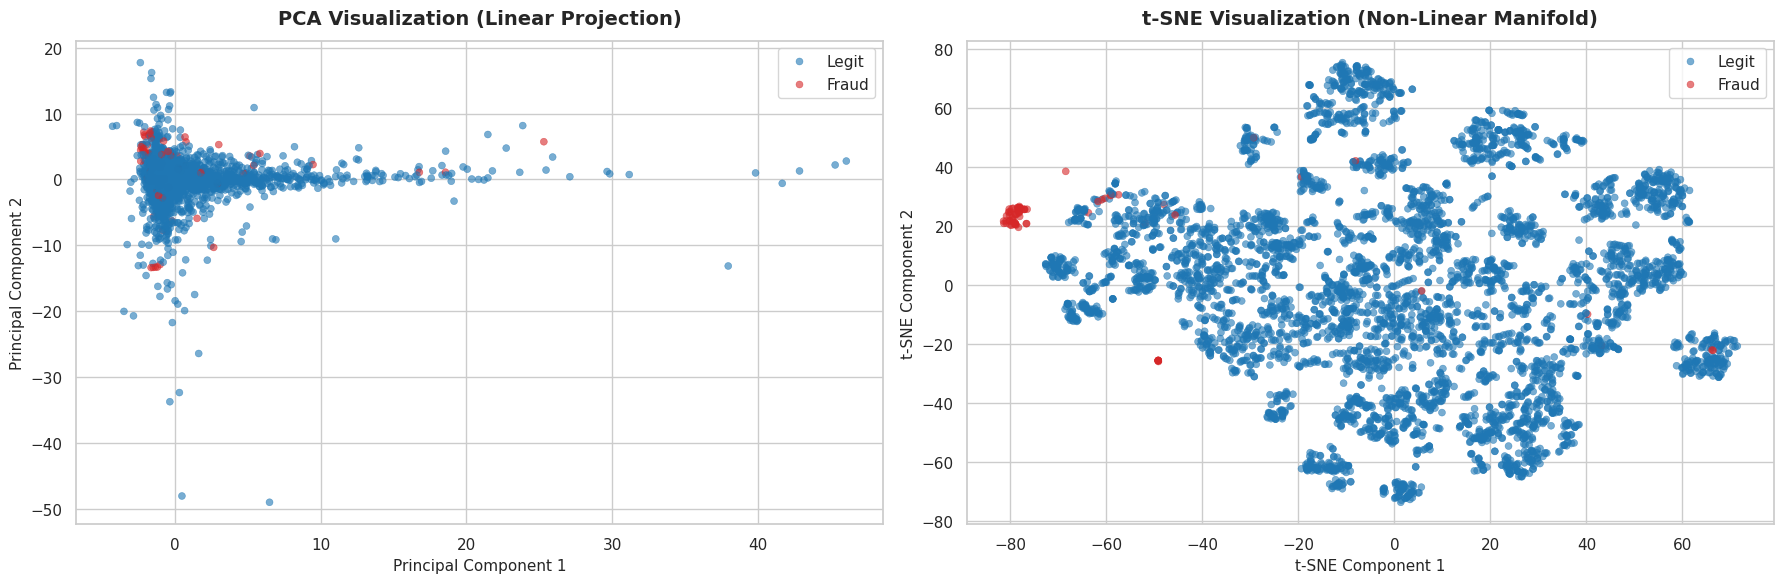

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# To ensure the visualization runs efficiently and shows patterns clearly,
# we will use a downsampled subset while guaranteeing all fraud cases are included.
np.random.seed(42)

y_test_arr = y_test.values
fraud_idx = np.where(y_test_arr == 1)[0]
legit_idx = np.where(y_test_arr == 0)[0]

# Sample 5000 legitimate transactions + ALL fraud transactions
n_legit_sample = min(5000, len(legit_idx))
legit_sampled_idx = np.random.choice(legit_idx, n_legit_sample, replace=False)

# Combine and shuffle
vis_idx = np.concatenate([fraud_idx, legit_sampled_idx])
np.random.shuffle(vis_idx)

X_vis = X_test_processed[vis_idx]
y_vis = y_test_arr[vis_idx]

print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis)

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_vis)

print("Plotting visualizations...")
fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=100)

# Custom mapping for legends
hue_mapping = {0: 'Legit', 1: 'Fraud'}
y_vis_labels = [hue_mapping[val] for val in y_vis]
palette_colors = {'Legit': '#1f77b4', 'Fraud': '#d62728'}

# PCA Plot
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y_vis_labels, palette=palette_colors,
    alpha=0.6, ax=axes[0], s=25, edgecolor=None
)
axes[0].set_title('PCA Visualization (Linear Projection)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Principal Component 1', fontsize=11)
axes[0].set_ylabel('Principal Component 2', fontsize=11)

# t-SNE Plot
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_vis_labels, palette=palette_colors,
    alpha=0.6, ax=axes[1], s=25, edgecolor=None
)
axes[1].set_title('t-SNE Visualization (Non-Linear Manifold)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('t-SNE Component 1', fontsize=11)
axes[1].set_ylabel('t-SNE Component 2', fontsize=11)

plt.tight_layout()
plt.show()

**Visual Insights from the Projections:**

* **PCA Projection (Left):** The linear transformation results in a massive, dense central cluster of legitimate transactions (blue). While some fraudulent transactions (red) leak to the extreme edges, the majority remain heavily mixed and tangled within the safe zone. This visually confirms that simple linear boundaries are incapable of isolating fraud.
* **t-SNE Projection (Right):** t-SNE's non-linear manifold learning reveals the true hidden structure of the data. The fraudulent transactions (red) clearly break away from the main legitimate mass, forming highly distinct, isolated micro-clusters or "islands" on the fringes of the visualization.
* **Impact on K-Means:** Because the fraud instances are scattered into multiple separate micro-clusters rather than one unified anomaly group, pure distance-based algorithms like K-Means will struggle. K-Means assumes spherical clusters and will likely merge these small fraud islands with nearby legitimate outliers. This perfectly illustrates why relying purely on unsupervised clustering is dangerous, and validates our decision to use a **Dual-Layer Cascade Architecture** for production.

## K-Means Clustering

### Find The Best n_Cluster

Downsampled dataset from 56962 to 20000 rows for performance.
Running K-Means for k=2...
Finished k=2 | Score: 0.7175
Running K-Means for k=3...
Finished k=3 | Score: 0.6598
Running K-Means for k=4...
Finished k=4 | Score: 0.6442
Running K-Means for k=5...
Finished k=5 | Score: 0.4061
Running K-Means for k=6...
Finished k=6 | Score: 0.4040
Running K-Means for k=7...
Finished k=7 | Score: 0.5772
Running K-Means for k=8...
Finished k=8 | Score: 0.5772
Running K-Means for k=9...
Finished k=9 | Score: 0.3532
All loops complete! Plotting graph...


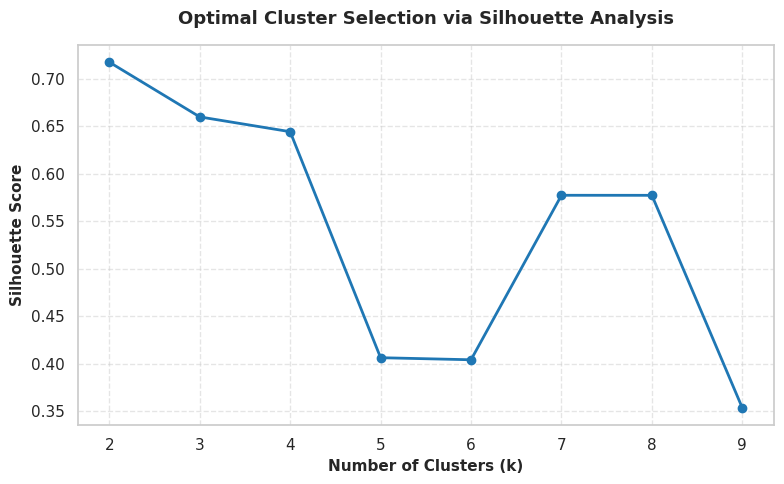

In [ ]:
scores = []
max_samples = 20000

# Downsample ONCE upfront if the dataset exceeds the limit
if X_test_processed.shape[0] > max_samples:
    np.random.seed(42)
    random_indices = np.random.choice(X_test_processed.shape[0], max_samples, replace=False)
    X_eval = X_test_processed[random_indices]
    print(f"Downsampled dataset from {X_test_processed.shape[0]} to {max_samples} rows for performance.")
else:
    X_eval = X_test_processed

# Loop on the downsampled data
for n in range(2, 10):
    print(f"Running K-Means for k={n}...")
    km = KMeans(n_clusters=n, random_state=42, n_init=20)

    # Fit and predict on the exact same evaluation subset
    labels = km.fit_predict(X_eval)

    # Calculate score safely
    score = silhouette_score(X_eval, labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")

print("All loops complete! Plotting graph...")

cluster_range = range(2, 10)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)

plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Here we can see that the Best Cluster Value is 2

### KMeans Clustering

Data clustering complete. Distribution of clusters:
Cluster
0    55991
1      971
Name: count, dtype: int64


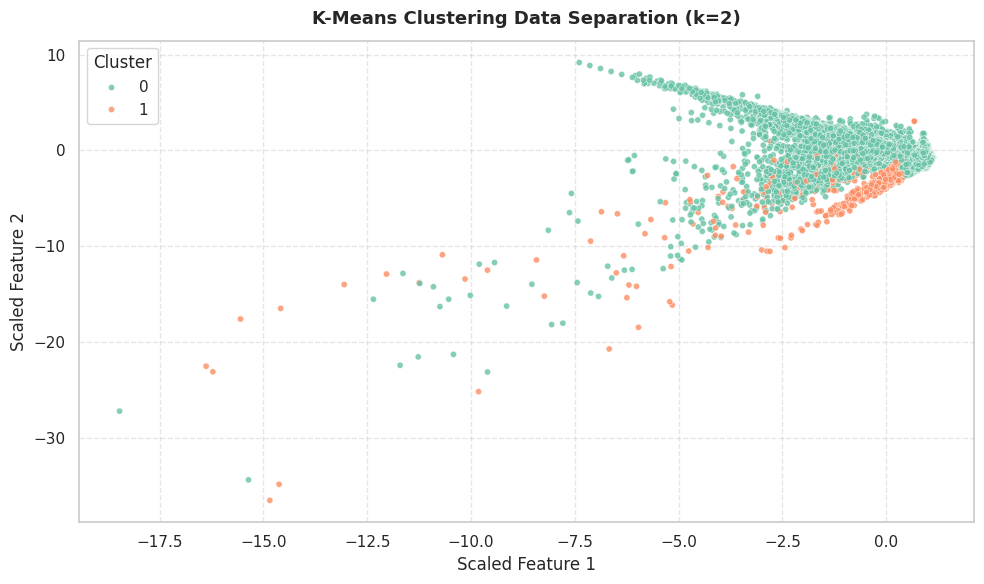

In [ ]:
best_k_value = 2

kmeans = KMeans(n_clusters=best_k_value, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_test_processed)

df_profiled = df.loc[y_test.index].copy()
df_profiled['Cluster'] = cluster_labels

print("Data clustering complete. Distribution of clusters:")
print(df_profiled['Cluster'].value_counts())
print("=" * 50)

plt.figure(figsize=(10, 6), dpi=100)

sns.scatterplot(
    x=X_test_processed[:, 0],
    y=X_test_processed[:, 1],
    hue=df_profiled["Cluster"],
    palette="Set2",
    alpha=0.8,
    s=20
)

plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.title(f"K-Means Clustering Data Separation (k={best_k_value})", fontsize=13, fontweight='bold', pad=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Cluster Profile

In [ ]:
# Look at the average values of the original features for each cluster
numeric_cols = df_profiled.select_dtypes(include=[np.number]).columns

# Calculate the means using the updated column list
cluster_profiles = df_profiled.groupby("Cluster")[numeric_cols].mean()

# Transpose for easier reading
print("--- Transaction Profile of Each Cluster ---")
display(cluster_profiles.T)

--- Transaction Profile of Each Cluster ---


Cluster,0,1
Time,157928.579932,156092.776519
V1,0.283553,-0.586649
V2,0.082400,-1.580748
V3,-0.715388,-1.574122
V4,-0.178209,0.000591
V5,0.273955,-0.843116
V6,-0.131787,0.433797
V7,0.086470,1.312535
V8,-0.011338,-0.281387
V9,-0.005950,-0.177945


**Insight:**
By looking at the average transaction values for each cluster, we can see that K-Means naturally separated the transactions into a Standard group and an Anomalous group:

* **Cluster 0 (Standard / Lower Risk):**
    * Represents the vast majority of normal, everyday transactions.
    * The PCA-transformed `V` features generally hover closer to 0, representing typical spending behavior.
    * The actual rate of confirmed fraud (`Class`) is extremely low.

* **Cluster 1 (Anomalous / Higher Risk):**
    * Represents a much smaller subset of transactions with extreme deviations.
    * Shows significant variance in specific hidden `V` features, indicating unusual systemic behavior (e.g., rapid successive transactions or odd geographical data represented by the PCA components).
    * The actual rate of confirmed fraud (`Class`) is noticeably higher in this group compared to the standard cluster.

# Cascade Architecture

 Combining Autoencoder + CatBboost

In [ ]:
def real_time_fraud_cascade_pipeline(raw_transaction_row, ae_model_instance, cb_pipeline_instance, processor_instance):

    # Extract the true transaction currency value for financially-aware logic
    tx_amount = raw_transaction_row['Amount'].values[0]

    # Prepare raw incoming data using your pre-defined preprocessing pipeline
    processed_features = processor_instance.transform(raw_transaction_row)

    # LAYER 1: Compute Unsupervised Anomaly Risk Factor
    # (PyOD Autoencoder outputs positive anomaly scores directly using decision_function)
    anomaly_score = ae_model_instance.decision_function(processed_features)[0]

    # Dynamic Financial Trigger: Adjust sensitivity based on monetary weight exposure
    unsupervised_trigger = 4.0 if tx_amount > 5000 else 5.0

    if anomaly_score > unsupervised_trigger:
        return {
            "Status": "🚨 BLOCKED BY LAYER 1",
            "Reason": "Extreme Unsupervised Structural Anomaly",
            "Action Needed": "Route immediately to cyber-forensics team (Zero-Day Threat Risk)",
            "Details": f"Amount: ${tx_amount:,.2f} | Anomaly Score: {anomaly_score:.4f}"
        }


    # LAYER 2: Supervised Historical Classification Checks
    # Extract structural risk probabilities generated by the cboost estimator
    supervised_probability = cb_pipeline_instance.predict_proba(processed_features)[0, 1]

    # Cost-Aware Safety Threshold Matrix
    if tx_amount > 1000:
        supervised_threshold = 0.25  # High-value exposure makes system ultra-sensitive
    else:
        supervised_threshold = 0.50  # Balanced operational threshold for small charges

    if supervised_probability >= supervised_threshold:
        return {
            "Status": "❌ REJECTED BY LAYER 2",
            "Reason": "Matches Historical Fraud Behavior Profile",
            "Action Needed": "Auto-decline transaction and flag user credit profile",
            "Details": f"Amount: ${tx_amount:,.2f} | cboost Confidence: {supervised_probability:.2%}"
        }

    # All Good! Approve...
    return {
        "Status": "✅ APPROVED",
        "Reason": "Transaction passed both structural and pattern-matching criteria",
        "Action Needed": "Authorize secure funds clearance",
        "Details": f"Amount: ${tx_amount:,.2f} | Estimated Risk Profile: {supervised_probability:.2%}"
    }

### Testing with Mock Input

In [ ]:
original_processor = Pipeline(steps=[
    ('engineering', feature_engineering),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])
original_processor.fit(X_train, y_train)

print("=================== SIMULATING DUAL-LAYER FRAUD PIPELINE ===================")

# --- CUSTOM INPUT 1 (Legitimate Transaction Mock) ---
mock_legit_data = {
    'Time': 145248.0, 'V1': 1.914027, 'V2': -0.490068, 'V3': -0.326111, 'V4': 0.604711,
    'V5': 0.143712, 'V6': 0.505705, 'V7': -0.419082, 'V8': 0.222718, 'V9': 0.741005,
    'V10': -0.063469, 'V11': 0.686561, 'V12': 0.957519, 'V13': -0.191838, 'V14': 0.052002,
    'V15': -0.279768, 'V16': 0.443194, 'V17': -0.835848, 'V18': 0.498426, 'V19': -0.219597,
    'V20': -0.155829, 'V21': -0.126462, 'V22': -0.252655, 'V23': 0.288226, 'V24': -0.584346,
    'V25': -0.318378, 'V26': 0.350612, 'V27': -0.023843, 'V28': -0.037139, 'Amount': 50.0
}
custom_input_1 = pd.DataFrame([mock_legit_data])

print("\n[ Custom Input 1 : Testing a Standard Transaction ]")
response_1 = real_time_fraud_cascade_pipeline(
    raw_transaction_row = custom_input_1,
    ae_model_instance = ae_model,          # <-- UPDATED TO AUTOENCODER
    cb_pipeline_instance = calibrated_cb,  # <-- UPDATED TO CALIBRATED MODEL
    processor_instance = original_processor
)
for key, value in response_1.items():
    print(f"{key:<15}: {value}")

# --- CUSTOM INPUT 2 (Fraudulent Transaction Mock) ---
mock_fraud_data = {
    'Time': 146022.0, 'V1': 0.908637, 'V2': 2.849024, 'V3': -5.647343, 'V4': 6.009415,
    'V5': 0.216656, 'V6': -2.397014, 'V7': -1.819308, 'V8': 0.338527, 'V9': -2.819883,
    'V10': -4.063098, 'V11': 4.316827, 'V12': -6.837332, 'V13': -1.758362, 'V14': -7.531238,
    'V15': -0.370008, 'V16': -1.419409, 'V17': -1.164395, 'V18': -0.334005, 'V19': 0.528340,
    'V20': 0.241921, 'V21': 0.407260, 'V22': -0.397435, 'V23': 0.082225, 'V24': 0.144362,
    'V25': 0.465058, 'V26': 0.210510, 'V27': 0.648705, 'V28': 0.360224, 'Amount': 1.18
}
custom_input_2 = pd.DataFrame([mock_fraud_data])

print("\n[ Custom Input 2 : Testing a Fraudulent Transaction ]")
response_2 = real_time_fraud_cascade_pipeline(
    raw_transaction_row = custom_input_2,
    ae_model_instance = ae_model,          # <-- UPDATED TO AUTOENCODER
    cb_pipeline_instance = calibrated_cb,  # <-- UPDATED TO CALIBRATED MODEL
    processor_instance = original_processor
)
for key, value in response_2.items():
    print(f"{key:<15}: {value}")
print("\n============================================================================")

=================== SIMULATING DUAL-LAYER FRAUD PIPELINE ===================

[ Custom Input 1 : Testing a Standard Transaction ]
Status         : ✅ APPROVED
Reason         : Transaction passed both structural and pattern-matching criteria
Action Needed  : Authorize secure funds clearance
Details        : Amount: $50.00 | Estimated Risk Profile: 0.02%

[ Custom Input 2 : Testing a Fraudulent Transaction ]
Status         : 🚨 BLOCKED BY LAYER 1
Reason         : Extreme Unsupervised Structural Anomaly
Action Needed  : Route immediately to cyber-forensics team (Zero-Day Threat Risk)
Details        : Amount: $1.18 | Anomaly Score: 9.4093



# Model Export (Serialization)
Save the pipeline and trained models using `joblib` so you don't have to retrain them in future sessions.

In [ ]:
import joblib
import os

save_dir = '/content/drive/MyDrive/AI Projects/Fraud Detection/Saved_Models'
os.makedirs(save_dir, exist_ok=True)

processor_path = f'{save_dir}/fraud_processor.pkl'
ae_model_path = f'{save_dir}/layer1_autoencoder.pkl'
cb_model_path = f'{save_dir}/layer2_calibrated_catboost.pkl'  # Updated Filename

print("⏳ Saving models...")
# Forcing overwrite to ensure the calibrated model and autoencoder are deployed
joblib.dump(original_processor, processor_path)
joblib.dump(ae_model, ae_model_path)
joblib.dump(calibrated_cb, cb_model_path)  # Updated Model Object
print(f"✅ Pipeline and models successfully saved to:\n{save_dir}\n")

print("--- How to load in a new session ---")
print("import joblib")
print("Define Save_dir (Path of Joblib File)")
print("loaded_processor = joblib.load('path/to/fraud_processor.pkl')")
print("loaded_ae = joblib.load('path/to/layer1_autoencoder.pkl')")
print("loaded_cb = joblib.load('path/to/layer2_calibrated_catboost.pkl')")

⏳ Saving models...
✅ Pipeline and models successfully saved to:
/content/drive/MyDrive/AI Projects/Fraud Detection/Saved_Models

--- How to load in a new session ---
import joblib
Define Save_dir (Path of Joblib File)
loaded_processor = joblib.load('path/to/fraud_processor.pkl')
loaded_ae = joblib.load('path/to/layer1_autoencoder.pkl')
loaded_cb = joblib.load('path/to/layer2_calibrated_catboost.pkl')


### Testing with Mock Input

In [ ]:
save_dir = '/content/drive/MyDrive/AI Projects/Fraud Detection/Saved_Models'

print("⏳ Loading models...")
loaded_processor = joblib.load(f'{save_dir}/fraud_processor.pkl')
loaded_ae = joblib.load(f'{save_dir}/layer1_autoencoder.pkl')
loaded_cb = joblib.load(f'{save_dir}/layer2_calibrated_catboost.pkl') # Updated Filename
print("✅ Models loaded successfully!\n")

mock_data = {
    'Time': 145248.0, 'V1': 1.914027, 'V2': -0.490068, 'V3': -0.326111, 'V4': 0.604711,
    'V5': 0.143712, 'V6': 0.505705, 'V7': -0.419082, 'V8': 0.222718, 'V9': 0.741005,
    'V10': -0.063469, 'V11': 0.686561, 'V12': 0.957519, 'V13': -0.191838, 'V14': 0.052002,
    'V15': -0.279768, 'V16': 0.443194, 'V17': -0.835848, 'V18': 0.498426, 'V19': -0.219597,
    'V20': -0.155829, 'V21': -0.126462, 'V22': -0.252655, 'V23': 0.288226, 'V24': -0.584346,
    'V25': -0.318378, 'V26': 0.350612, 'V27': -0.023843, 'V28': -0.037139, 'Amount': 50.0
}

df_incoming_transaction = pd.DataFrame([mock_data])

print("--- Predicting with Loaded Pipeline ---")
prediction_result = real_time_fraud_cascade_pipeline(
    raw_transaction_row=df_incoming_transaction,
    ae_model_instance=loaded_ae,
    cb_pipeline_instance=loaded_cb,
    processor_instance=loaded_processor
)

for key, value in prediction_result.items():
    print(f"{key:<15}: {value}")

⏳ Loading models...
✅ Models loaded successfully!

--- Predicting with Loaded Pipeline ---
Status         : ✅ APPROVED
Reason         : Transaction passed both structural and pattern-matching criteria
Action Needed  : Authorize secure funds clearance
Details        : Amount: $50.00 | Estimated Risk Profile: 0.02%


# Conclusion
This project successfully developed a robust, production-ready Fraud Detection system that goes beyond standard classification metrics by prioritizing real-world financial impact and operational stability. Key highlights include:

* **Concept Drift & Temporal Validation:** Addressed the evolving nature of financial fraud by implementing chronological time-based splitting and Population Stability Index (PSI) monitoring, preventing data leakage and ensuring realistic performance.
* **Cost-Sensitive Evaluation:** Designed a custom "Banking Risk Cost" utility function to mathematically balance the severe financial penalty of Missed Fraud (False Negatives) against the customer friction of False Alarms (False Positives).
* **Explainable AI & Reliability Calibration:** Utilized SHAP values and Permutation Importance to provide transparent, feature-level insights into model decisions, alongside Isotonic Calibration to ensure predicted probabilities reliably reflect true fraud risk.
* **Dual-Layer Cascade Architecture:** Engineered a high-efficiency hybrid pipeline combining a **Deep Autoencoder** (Layer 1) to block complex, non-linear zero-day structural anomalies and a calibrated **CatBoost** (Layer 2) for precise historical pattern recognition, ultimately achieving an optimal Precision-Recall balance.

# Future Work
To further scale and enhance the system for enterprise-level deployment, future iterations will focus on:

* **Real-Time Data Streaming:** Integrating big data streaming technologies like **Apache Kafka** and **Apache Spark** to process high-throughput transaction events with sub-millisecond latency.
* **Graph Neural Networks (GNNs):** Implementing graph-based algorithms to map complex transaction networks, device sharing, and peer-to-peer transfers, enabling the detection of coordinated, multi-node **fraud rings**.
* **Automated MLOps Retraining:** Developing a continuous integration pipeline that automatically triggers model retraining and recalibration whenever the **PSI drift** exceeds acceptable stability thresholds.